# Khám phá Phát hiện Gian lận với Neo4j & Khoa học Dữ liệu Đồ thị

Phân tích này sử dụng [Neo4j và Khoa học Dữ liệu Đồ thị (GDS)](https://neo4j.com/docs/graph-data-science/current/) để khám phá một mẫu dữ liệu ẩn danh từ nền tảng thanh toán ngang hàng (P2P). Notebook được chia thành các phần sau để bao gồm các giai đoạn khác nhau của quy trình làm việc khoa học dữ liệu đồ thị:

- Thiết lập Notebook
- Phần 1: Khám phá Dữ liệu Gian lận được Kết nối
- Phần 2: Giải quyết Cộng đồng Gian lận bằng cách Sử dụng Giải quyết Thực thể và Phát hiện Cộng đồng
- Phần 3: Đề xuất Tài khoản Đáng ngờ với Độ tập trung & Độ tương đồng Nút
- Phần 4: Dự đoán Tài khoản Rủi ro Gian lận bằng Học máy

## Thiết lập Notebook <a name="p0"></a>

In [1]:
import pandas as pd
import configparser
import os
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', 500)
pd.set_option('display.max_rows', 50)

**Bước 1: Cài đặt và Hiển thị Pandas**
Đoạn code này xử lý phần cài đặt hiển thị Pandas để đảm bảo các dòng dữ liệu dài trong notebook không bị cắt bớt và được format cho dễ nhìn.

### Cài đặt Neo4j
Tệp `NEO4J_PROPERTIES_FILE` là tệp cấu hình ini cho các thuộc tính của Neo4j để sổ tay này có thể kết nối với
phiên bản Neo4j của bạn và tải dữ liệu. Tệp ini nên được định dạng như sau:
```
[NEO4J]
PASSWORD=<mật khẩu>
USERNAME=<tên cơ sở dữ liệu, mặc định là 'neo4j'>
HOST=<địa chỉ máy chủ>
```

Đặt `NEO4J_PROPERTIES_FILE` thành None hoặc bất kỳ vị trí không tồn tại nào để sử dụng các giá trị mặc định bên dưới:
```
HOST = 'neo4j://localhost'
USERNAME = 'neo4j'
PASSWORD = 'mật khẩu'
```

In [2]:
NEO4J_PROPERTIES_FILE = '/Users/zachblumenfeld/devtools/auth/aura-p2p-fd.ini'

**Cấu hình kết nối Neo4j (File)**
Chỉ định đường dẫn đến file tệp `.ini` chứa thông tin đăng nhập Neo4j. Điều này hữu ích khi bạn không muốn công khai mật khẩu trong mã nguồn.

In [3]:
## Sử dụng tệp ini để lưu thông tin đăng nhập, nếu không thì sử dụng các giá trị mặc định.
HOST = 'neo4j://localhost'
USERNAME = 'neo4j'
PASSWORD = '12345678'

if NEO4J_PROPERTIES_FILE is not None and os.path.exists(NEO4J_PROPERTIES_FILE):
    config = configparser.RawConfigParser()
    config.read(NEO4J_PROPERTIES_FILE)
    HOST = config['NEO4J']['HOST']
    USERNAME = config['NEO4J']['USERNAME']
    PASSWORD = config['NEO4J']['PASSWORD']
    print('Using custom database properties')
else:
    print('Could not find database properties file, using defaults')

Could not find database properties file, using defaults


**Cấu hình kết nối (Dự phòng ngầm định)**
Kiểm tra xem file cấu hình có tồn tại không. Nếu có thì nạp HOST, USERNAME và PASSWORD, nếu không thì dùng `neo4j://localhost` mặc định.

### Kết nối với Graph Data Science

In [4]:
from graphdatascience import GraphDataScience

# Use Neo4j URI and credentials according to your setup
gds = GraphDataScience(HOST, auth=(USERNAME, PASSWORD), aura_ds=False)

**Khởi tạo kết nối với Neo4j thông qua GDS Client**
Sử dụng module `GraphDataScience` từ GDS Python client, cung cấp chuỗi kết nối và chứng chỉ (auth) để bắt đầu phân tích với bộ dữ liệu trên Aura hoặc Local.

### Các hàm hỗ trợ

In [5]:
def clear_graph_by_name(g_name):
    if gds.graph.exists(g_name).exists:
        g = gds.graph.get(g_name)
        gds.graph.drop(g)

def clear_all_graphs():
    g_names = gds.graph.list().graphName.tolist()
    for g_name in g_names:
        g = gds.graph.get(g_name)
        gds.graph.drop(g)

def identifier_degrees(user_label, degree_property):
    g_name = 'id-projection'
    clear_graph_by_name(g_name)
    g, _  = gds.graph.project(g_name, [user_label, 'Card', 'Device', 'IP'],{
        'HAS_CC': {'orientation': 'REVERSE'},
        'HAS_IP': {'orientation': 'REVERSE'},
        'USED': {'orientation': 'REVERSE'}
    })
    gds.degree.mutate(g, mutateProperty=degree_property)
    gds.graph.writeNodeProperties(g, [degree_property], ['Card', 'Device', 'IP'])
    g.drop()

**Các Hàm Hỗ Trợ Đồ Thị (Helper Functions)**
Định nghĩa 3 hàm Python tái sử dụng: 
 - `clear_graph_by_name`: Xóa một in-memory graph xác định.
 - `clear_all_graphs`: Dọn dẹp toàn bộ đồ thị bộ nhớ.
 - `identifier_degrees`: Hàm tự động tính toán 'Bậc' (Degree) kết nối giữa User và Thẻ(Card), Thiết Bị (Device), hoặc IP thông qua module GDS.

## Phần 1: Khám phá dữ liệu gian lận liên kết

### Giới thiệu về bộ dữ liệu

Chúng tôi sẽ sử dụng một mẫu dữ liệu ẩn danh gồm các tài khoản người dùng và giao dịch từ một nền tảng Peer-to-Peer (P2P) thực tế. Trước khi đưa dữ liệu vào đồ thị, các số định danh ban đầu đã được loại bỏ và các giá trị phân loại đã được che giấu. Mỗi tài khoản người dùng có một mã định danh 128 bit duy nhất, trong khi các nút khác, đại diện cho các thẻ tín dụng, thiết bị và địa chỉ IP duy nhất, đã được gán các UUID ngẫu nhiên. Các mã định danh này được lưu trữ dưới dạng thuộc tính guid trong lược đồ thị.

Dưới đây là hình ảnh trực quan về lược đồ thị:

<img src="img/schema.png" width="500" >

Mỗi nút người dùng có một biến chỉ báo về gian lận chuyển tiền (có tên là MoneyTransferFraud) với giá trị là 1 nếu đã biết có gian lận và 0 nếu không. Chỉ báo này được xác định bởi sự kết hợp giữa các sự kiện hoàn trả thẻ tín dụng và xem xét thủ công. Hoàn trả là hành động được thực hiện bởi ngân hàng để đảo ngược các khoản thanh toán điện tử. Nó bao gồm việc đảo ngược một khoản thanh toán và kích hoạt quy trình giải quyết tranh chấp, thường là do lỗi lập hóa đơn và sử dụng tín dụng trái phép. Tóm lại, một người dùng phải có ít nhất một lần hoàn tiền (chargeback) mới bị coi là gian lận. Chỉ một tỷ lệ nhỏ các tài khoản người dùng, khoảng 0,7%, bị gắn cờ là gian lận.

Mỗi nút người dùng có một biến chỉ báo về gian lận chuyển tiền (có tên là `MoneyTransferFraud`) có giá trị là 1 nếu đã biết có gian lận và 0 nếu không. Chỉ báo này được xác định bằng sự kết hợp giữa các sự kiện hoàn tiền thẻ tín dụng và việc xem xét thủ công. Hoàn tiền là hành động mà ngân hàng thực hiện để đảo ngược các khoản thanh toán điện tử. Nó bao gồm việc đảo ngược khoản thanh toán và kích hoạt quy trình giải quyết tranh chấp, thường là do lỗi thanh toán và sử dụng tín dụng trái phép. Tóm lại, một người dùng phải có ít nhất một lần hoàn tiền mới bị coi là gian lận. Chỉ một tỷ lệ nhỏ các tài khoản người dùng, khoảng 0,7%, bị gắn cờ là gian lận.

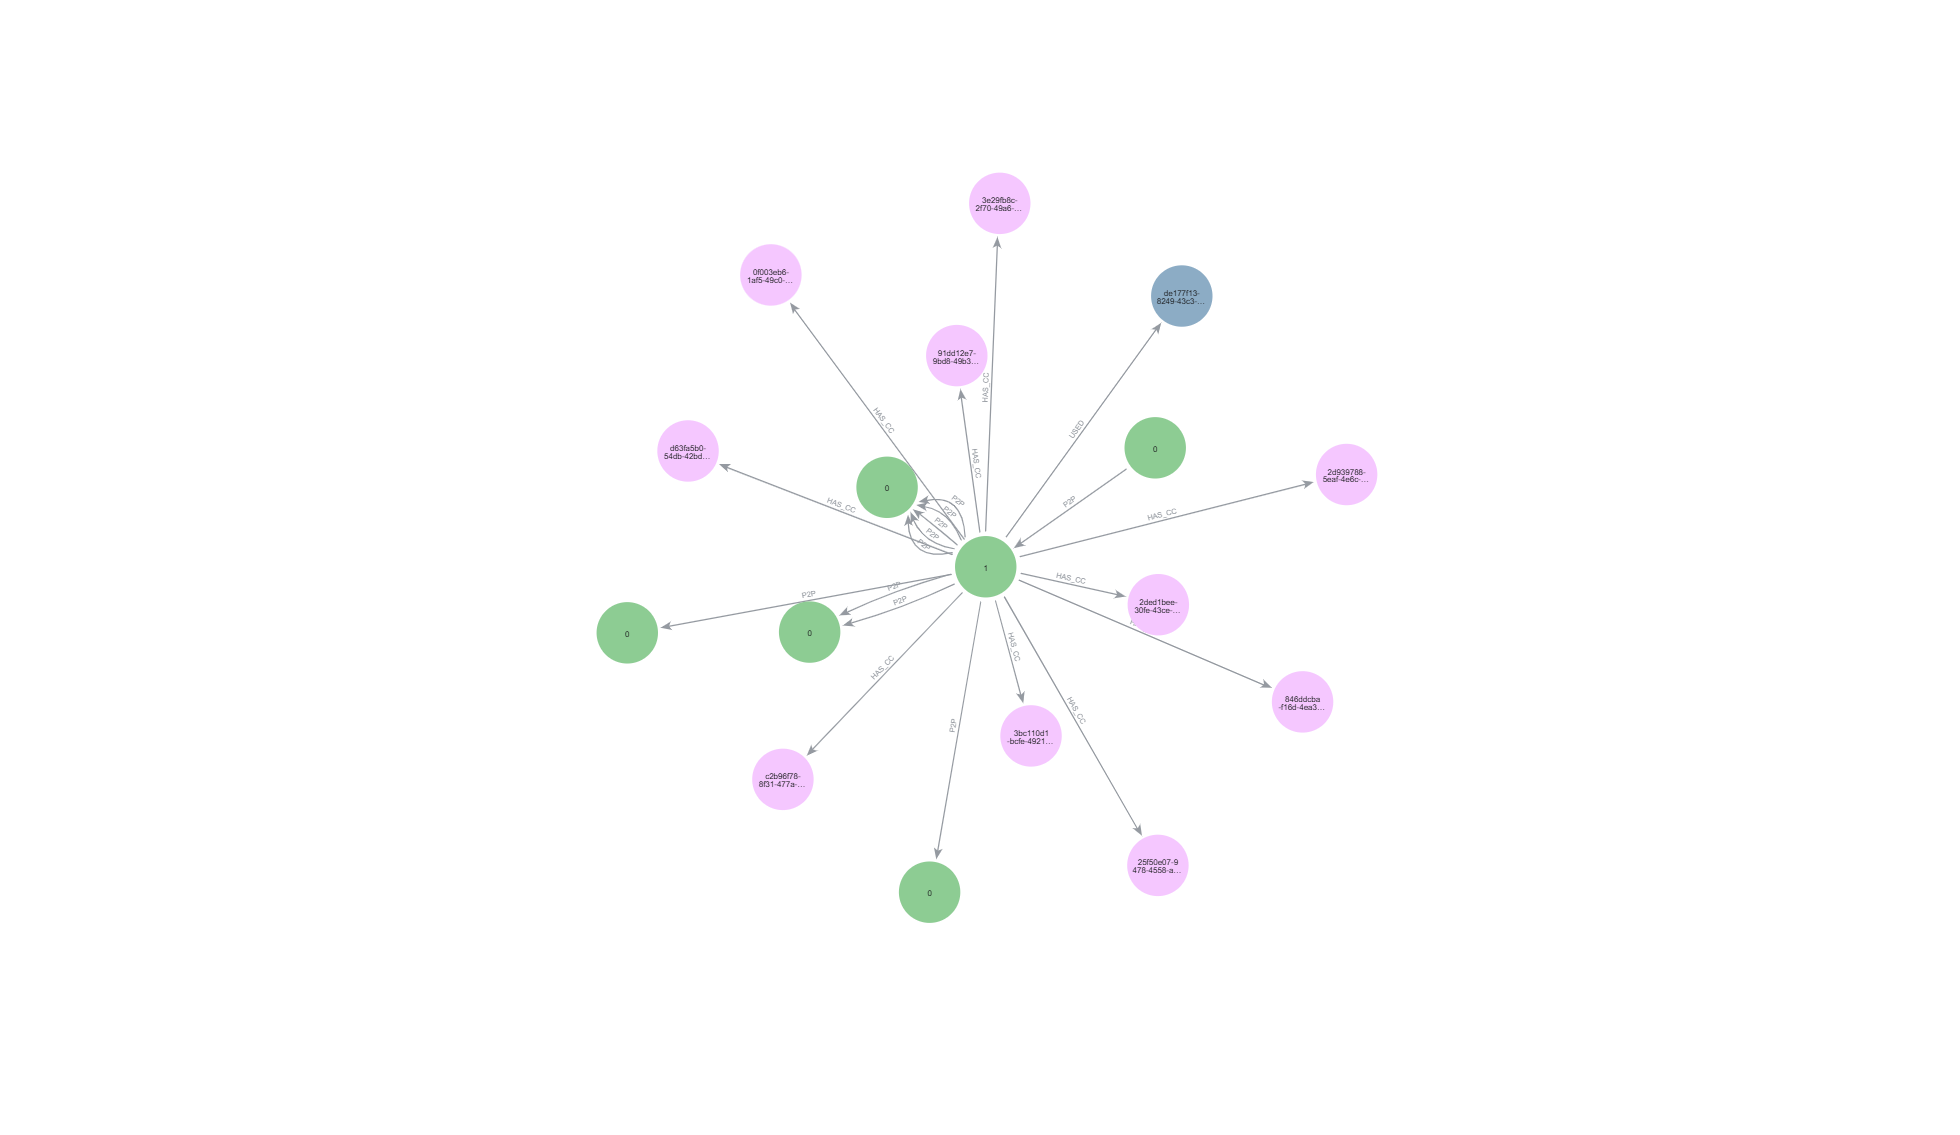

Dưới đây là bảng phân tích số liệu tổng quan theo nhãn và mối quan hệ, cũng như các tài khoản được gắn cờ.

In [6]:
# Tổng số node
gds.run_cypher('''
    CALL apoc.meta.stats()
    YIELD labels
    UNWIND keys(labels) AS nodeLabel
    RETURN nodeLabel, labels[nodeLabel] AS nodeCount
''')

,nodeLabel,nodeCount
0,User,33731
1,FlaggedUser,240
2,Device,51451
3,Card,118818
4,IP,585855


**Thống Kê Nhãn Nút Phân Loại (Node Count)**
Truy vấn Cypher bằng `apoc.meta.stats` để kiểm kê số lượng các loại đối tượng đang có trong đồ thị (User, Device, Card, IP).

In [7]:
# Tổng số relationship
gds.run_cypher('''
    CALL apoc.meta.stats()
    YIELD relTypesCount
    UNWIND keys(relTypesCount) AS relationshipType
    RETURN relationshipType, relTypesCount[relationshipType] AS relationshipCount
''')

,relationshipType,relationshipCount
0,USED,55024
1,HAS_IP,1488946
2,HAS_CC,128063
3,REFERRED,1870
4,P2P,102829


**Thống Kê Kiểu Quan Hệ (Relationship Count)**
Lấy thông kê từ `apoc` về số lượng liên kết (Edge) cho các loại quan hệ thực tế: như người dùng 'DÙNG' thiết bị, 'CÓ' IP hoặc 'CÓ' Card.

In [8]:
# Cảnh báo fraud money transfer 
gds.run_cypher('MATCH(u:User) RETURN u.fraudMoneyTransfer AS fraudMoneyTransfer, count(u) AS cnt')

,fraudMoneyTransfer,cnt
0,0,33491
1,1,240


**Thiết Lập Nhãn Gian Lận Gốc**
Truy vấn đếm tổng số User đã được gắn cờ là gian lận trong giao dịch P2P từ dữ liệu thu thập thô. Chỉ báo này (fraudMoneyTransfer=1) tượng trưng cho gian lận (Chargebacks).

### Phân tích kỹ hơn về Thẻ và Thiết bị

Qua điều tra ban đầu về số liệu thống kê tổng hợp, các tài khoản được gắn nhãn gian lận dường như không có mối liên hệ chặt chẽ, điều này đương nhiên khiến người ta nghi ngờ về phương pháp dựa trên đồ thị. Điều này được minh họa rõ nét bởi sự thiếu phân biệt trong các định danh chính.

Bước đầu tiên, tôi phân tích tỷ lệ người dùng gian lận so với người dùng không gian lận được kết nối với thẻ tín dụng và thiết bị bên dưới. Tôi nhận thấy rằng rất ít thẻ hoặc thiết bị tập trung tốt xung quanh các tài khoản bị gắn cờ. Điều này khá bất ngờ đối với tôi. Nếu một thẻ hoặc thiết bị được sử dụng bởi một tài khoản bị gắn cờ, tôi sẽ kỳ vọng các tài khoản khác sử dụng thẻ/thiết bị đó cũng sẽ bị gắn cờ gian lận.

In [9]:
# Việc gán nhãn cho người dùng được gắn cờ sẽ cho phép tra cứu nhanh hơn trong cypher và chiếu dữ liệu gds nhanh hơn.
gds.run_cypher('MATCH(u:User) WHERE u.fraudMoneyTransfer=1 SET u:FlaggedUser RETURN count(u)')

,count(u)
0,240


**Gán Nhãn FlaggedUser trên Đồ thị để Quản lý**
Biến các tài khoản có cột gian lận bằng 1 thành một Label `FlaggedUser` thực sự trên Neo4j để tối ưu tốc độ đọc truy vấn và tính toán với GDS về sau.

In [10]:
# Sử dụng độ trung tâm GDS để đếm số lượng Người dùng được kết nối với từng loại định danh - Thẻ, Thiết bị, IP
# Gán độ cho nút card, device, ip có kết nối tới người dùng
identifier_degrees('User', 'degree')
# Sử dụng độ trung tâm GDS để đếm số lượng Người dùng được gắn cờ được kết nối với từng loại định danh - Thẻ, Thiết bị, IP
# Gán độ cho nút card, device, ip có kết nối tới người dùng gian lận
identifier_degrees('FlaggedUser', 'flaggedDegree')

# Tính tỷ lệ người dùng được gắn cờ so với tổng số người dùng
#Tính % người dùng gian lận / người dùng của nút card, device, ip
gds.run_cypher('''
    MATCH(n) WHERE n:Card OR n:Device OR n:IP
    SET n.flaggedRatio = toFloat(n.flaggedDegree)/toFloat(n.degree)
''')

""


**Chỉ Số Cắm Cờ Gian Lận (Tỷ lệ bị gán cờ)**
Sử dụng hàm tự định nghĩa tính toán Bậc của User tới các Device/IP/Card, sau đó tính tỷ lệ Bậc (Degree) của `FlaggedUser` so với toàn bộ User đang kết nối. Kết quả này đo lường sự cô lập của kẻ gian lận.

In [11]:
print('Flagged User Ratio for Card Count')
#In ra % các nút Card có kết nối ít nhất 2 người dùng (degree > 1)
gds.run_cypher("""
MATCH (n:Card)
WHERE n.degree > 1
WITH count(n) AS total

MATCH (n:Card)
WHERE n.degree > 1
WITH n, total,
CASE
    WHEN n.flaggedRatio = 0 THEN '0'
    WHEN n.flaggedRatio = 1 THEN '1'
    ELSE 'Between 0-1'
END AS flaggedUserRatio

WITH flaggedUserRatio, total, count(n) AS cnt
RETURN flaggedUserRatio,
       cnt AS count,
       round(toFloat(cnt) / total, 3) AS percentCount
ORDER BY flaggedUserRatio
""")

Flagged User Ratio for Card Count


,flaggedUserRatio,count,percentCount
0,0,8185,0.964
1,1,31,0.004
2,Between 0-1,273,0.032


**Phân Tích Tỷ Lệ Thẻ bị đánh dấu (Card Flagged Ratio)**
Tăng cường phân loại các Thẻ tín dụng đã dùng nặc danh: Thống kê xem Thẻ đó phục vụ toàn người dùng không liên đới (0), tài khoản liên đới toàn phần (1), hay đang nằm mức giữa hai ranh giới đó.

In [12]:
print('Flagged User Ratio for Device Count')
#In ra % các nút Deveice có kết nối ít nhất 2 người dùng (degree > 1)
gds.run_cypher("""
MATCH (n:Device)
WHERE n.degree > 1
WITH count(n) AS total

MATCH (n:Device)
WHERE n.degree > 1
WITH n, total,
CASE
    WHEN n.flaggedRatio = 0 THEN '0'
    WHEN n.flaggedRatio = 1 THEN '1'
    ELSE 'Between 0-1'
END AS flaggedUserRatio

WITH flaggedUserRatio, total, count(n) AS cnt
RETURN flaggedUserRatio,
       cnt AS count,
       round(toFloat(cnt) / total, 3) AS percentCount
ORDER BY flaggedUserRatio
""")

Flagged User Ratio for Device Count


,flaggedUserRatio,count,percentCount
0,0,2655,0.967
1,1,2,0.001
2,Between 0-1,88,0.032


**Phân Tích Thiết Bị bị đánh dấu (Device Flagged Ratio)**
Áp dụng phương pháp y hệt như trên với các thiết bị dùng chung để tìm kiếm mức độ liên đới thiết bị của người dùng gắn cờ gian lận.

#### Khám phá các mô hình gian lận tiềm ẩn bằng phương pháp phát hiện cộng đồng

Trong ví dụ này, tôi không rõ chính xác điều gì đang xảy ra, và tôi linh cảm rằng hoạt động gian lận không được gắn nhãn hoàn toàn do thiếu kết nối và logic hoàn trả hạn chế được sử dụng để gắn cờ gian lận. Đồng thời, tôi không muốn chỉ đơn giản gắn nhãn cho mọi người dùng chia sẻ thẻ hoặc thiết bị với một tài khoản bị gắn cờ khác, vì có khả năng thiết bị và/hoặc thẻ của một người dùng vô hại đã bị người khác sử dụng một cách gian lận. Vì những kẻ gian lận đang tích cực tránh bị nhận dạng, nên những kẻ thực hiện hành vi gian lận thường không chỉ được đại diện bởi một tài khoản người dùng duy nhất, mà là bởi nhiều tài khoản và định danh, mà hy vọng là có một số kết nối và điểm tương đồng.

Trong một đồ thị, chúng ta có thể cố gắng xác định sơ bộ các danh tính phân mảnh này bằng phương pháp phát hiện cộng đồng, một tập hợp lớn các phương pháp cố gắng phân chia đồ thị thành các nhóm được kết nối tốt, hay còn gọi là cộng đồng, trong đó khả năng kết nối trong cộng đồng cao hơn đáng kể so với bên ngoài cộng đồng. Có nhiều hình thức phát hiện cộng đồng. Chúng ta sẽ sử dụng một vài hình thức trong bài viết này, bắt đầu với Louvain.

#### Sử dụng thuật toán phát hiện cộng đồng Louvain

[Louvain](https://neo4j.com/docs/graph-data-science/current/algorithms/louvain/) rất hữu ích cho việc phân tích khám phá các cộng đồng vì nó sử dụng một hình thức chấm điểm tính mô-đun để chia đồ thị thành các cụm phân cấp. Điều này có nghĩa là các lý thuyết của bạn về các mô hình gian lận và cấu trúc đồ thị không cần phải chính xác để nó cung cấp các cộng đồng và thông tin chi tiết có ý nghĩa.

Tôi sẽ tận dụng các giao dịch P2P, thẻ và thiết bị cho Louvain. Chúng ta sẽ tạm thời bỏ qua địa chỉ IP vì chúng có một số vấn đề về siêu nút (chúng ta sẽ tận dụng địa chỉ IP trong các phần tiếp theo). Dưới đây là các truy vấn để chạy Louvain trong Neo4j GDS và tổng hợp số liệu thống kê cộng đồng. Truy vấn cuối cùng bên dưới sắp xếp các cộng đồng theo số lượng người dùng bị gắn cờ để chúng ta có thể xem xét kỹ hơn một số cộng đồng bị gắn cờ tập trung hơn.

In [13]:
# Hãy xóa đồ thị nếu nó tồn tại trước đó.
clear_graph_by_name('comm-projection')

g, _ = gds.graph.project('comm-projection', ['User','Card', 'Device'], {
    'HAS_CC': {'orientation': 'UNDIRECTED'},
    'USED': {'orientation': 'UNDIRECTED'},
    'P2P': {'orientation': 'NATURAL', 'aggregation': 'SINGLE'}
})

df = gds.louvain.write(g, writeProperty='louvainCommunityId')
g.drop()

# writeMillis: thời gian ghi kết quả phân cụm vào thuộc tính louvainCommunityId
# nodePropertiesWritten: Số lượng nút được phân cụm là 204,000
# modularity: Đây là chỉ số Modularity cuối cùng, đạt 0.981
# modularities: Mỗi giá trị tương ứng với modularity ở từng cấp độ phân cụm. Giá trị modularity tăng dần qua các cấp độ, cho thấy thuật toán tiếp tục cải thiện phân cụm cho đến khi đạt ngưỡng tốt nhất.
# ranLevels:Thuật toán đã chạy 10 cấp độ phân cụm để đạt được modularity tối ưu.
# communityCount:Số lượng cộng đồng được phát hiện là 11,662
# communityDistributionmin: 1 → Vẫn có cộng đồng nhỏ nhất chỉ với 1 nút.
# max: 3643 → Cộng đồng lớn nhất có 3,643 nút.
# mean: 17.49 → Kích thước trung bình mỗi cộng đồng là khoảng 17 nút.
# còn lại là hiệu năng cấu hình 

 Louvain:   5%|4         | 4.74/100 [00:00<?, ?%/s]

graphName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    comm-projection
database                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

**Thuật toán Phát Hiện Cộng Đồng: LOUVAIN**
Đưa đồ thị (Người Dùng, Thẻ, Thiết bị, P2P) chiếu vào bộ nhớ để tìm các tập hợp đồ thị mật thiết (cộng đồng). Quá trình này giúp gộp chung nhóm người dùng có số lượng liên kết chồng chéo nhau dày đặc thành `louvainCommunityId`.

In [14]:
# In cộng đồng và tỉ lệ người dùng gian lận 
print("Louvain Communities Ordered by count of Flagged Users")
gds.run_cypher('''
    MATCH (u:User)
    WITH u.louvainCommunityId AS community,
        count(u) AS cnt,
        sum(u.fraudMoneyTransfer) as flaggedCount
    RETURN community,
        cnt,
        flaggedCount,
        toFloat(flaggedCount)/toFloat(cnt) AS flaggedRatio
    ORDER BY flaggedCount DESC LIMIT 100
''')

Louvain Communities Ordered by count of Flagged Users


,community,cnt,flaggedCount,flaggedRatio
0,25771,152,7,0.046053
1,182733,7,4,0.571429
2,35239,7,3,0.428571
3,176956,3,3,1.000000
4,170836,567,3,0.005291
...,...,...,...,...
95,102313,6,1,0.166667
96,5799,4,1,0.250000
97,197526,176,1,0.005682
98,180420,53,1,0.018868


**Xếp Chỉ Số rủi ro cho Cộng Đồng Louvain**
Sau khi chia nhóm xong, sắp xếp chúng theo số lượng người dùng Gian Lận phân bố. Giúp theo dõi sự bất thường (một nhóm dính líu rất nhiều đến báo cáo độc hại).

Chúng ta có thể xem các cộng đồng người dùng và các định danh kết nối trong [Neo4j Bloom](https://neo4j.com/docs/bloom-user-guide/current/) hoặc Neo4j Browser với các truy vấn có dạng:

```cypher
MATCH(u1:User{louvainCommunityId: $id})-[r1:HAS_CC|HAS_IP|USED]->(n)<-[r2:HAS_CC|HAS_IP|USED]-(u2:User{louvainCommunityId: $id})
WITH *
OPTIONAL MATCH (u1)-[:P2P]-(u2)
RETURN *
``` 
Dưới đây là một vài ví dụ về các cộng đồng này. Người dùng bị gắn cờ được tô màu đỏ với chú thích=1, trong khi những người dùng khác được tô màu cam và chú thích=0. Chúng ta sẽ thấy một mô hình thú vị là những người dùng bị gắn cờ gửi tiền cho những người dùng không bị gắn cờ mà họ cùng sử dụng thiết bị, thẻ và địa chỉ IP. Hành vi này đáng ngờ vì nó cho thấy cùng một cá nhân hoặc một nhóm cá nhân có thể đang sử dụng nhiều tài khoản để rút tiền mặt từ các giao dịch thẻ tín dụng trước khi giao dịch hoàn tiền được thực hiện trên thẻ. Các ví dụ về thẻ tín dụng dùng chung (như ví dụ 2 bên dưới) là một số ví dụ điển hình nhất.

Ví dụ 1:
<img src="img/louvain-community-11.png" width="900" >

Ví dụ 2:
<img src="img/louvain-community-12.png" width="900" >

Mẫu này cho thấy các tài khoản người dùng nhận được là các tài khoản có nguy cơ gian lận. Trong phần tiếp theo, chúng ta sẽ sử dụng các mẫu này để hỗ trợ việc giải quyết các cộng đồng gian lận và gắn nhãn cho các tài khoản có nguy cơ gian lận khác.

## Phần 2: Giải quyết các cộng đồng gian lận bằng cách sử dụng phân giải thực thể và phát hiện cộng đồng

Việc xác định các cộng đồng phản ánh các nhóm cá nhân tiềm ẩn thường là một bước quan trọng trong việc phát hiện gian lận. Chúng ta đã khám phá điều này với Louvain; trong phần này, chúng ta sẽ cung cấp các định nghĩa chính thức hơn cho việc phân giải thực thể, cho phép chúng ta phân vùng các cộng đồng được xác định rõ ràng một cách có thể mở rộng.

Để thực hiện điều này, chúng ta sẽ định nghĩa một số quy tắc Phân giải Thực thể (ER) cho phép chúng ta thiết lập mối quan hệ giữa những người dùng mà chúng ta tin rằng thuộc cùng một cộng đồng tiềm ẩn. Sau đó, chúng ta sẽ sử dụng thuật toán [Weakly Connected Components (WCC)](https://neo4j.com/docs/graph-data-science/current/algorithms/wcc/) để phân giải các cộng đồng. Cuối cùng, chúng ta sẽ gắn nhãn tất cả người dùng trong các cộng đồng bao gồm các tài khoản được gắn cờ là có nguy cơ gian lận.

### Quy tắc nghiệp vụ phân giải thực thể

Bây giờ chúng ta sẽ sử dụng Phân giải Thực thể (ER) để phân giải các nhóm cá nhân đứng sau các tập hợp tài khoản người dùng. Đối với phân tích này, chúng ta sẽ sử dụng một số logic nghiệp vụ ER khá đơn giản. Nếu một trong hai điều kiện dưới đây đúng, chúng ta sẽ phân giải hai tài khoản người dùng bằng cách liên kết chúng với nhau bằng một loại mối quan hệ mới.

1. Một người dùng đã gửi tiền cho một người dùng khác có cùng thẻ tín dụng.
2. Hai người dùng có chung một thẻ hoặc thiết bị được kết nối với tổng số tài khoản nhỏ hơn hoặc bằng 10, và hai người dùng đó cũng có chung ít nhất hai định danh khác thuộc loại thẻ tín dụng, thiết bị hoặc địa chỉ IP.

Bạn có thể thay thế hoặc thêm các quy tắc khác vào các ví dụ trên, đây chỉ là ví dụ. Trong một kịch bản thực tế, các quy tắc nghiệp vụ này sẽ được các chuyên gia đánh giá và có thể được hỗ trợ thêm bởi học máy có giám sát trên dữ liệu được gắn nhãn thủ công. Các kỹ thuật nâng cao hơn cho loại ER này có thể được sử dụng trong đồ thị và chúng tôi mô tả chúng trong [báo cáo này](https://neo4j.com/whitepapers/graph-data-science-use-cases-entity-resolution/) và [bài đăng trên blog này](https://neo4j.com/developer-blog/exploring-supervised-entity-resolution-in-neo4j/).

Đối với tập dữ liệu P2P, chúng ta không nhất thiết phải gắn nhãn tất cả người gửi/người nhận của các giao dịch người dùng bị gắn cờ là gian lận vì một số hình thức gian lận liên quan đến các giao dịch với nạn nhân. Hơn nữa, các định danh bổ sung như địa chỉ IP có thể không chính xác và thẻ + thiết bị có thể bị kiểm soát/sử dụng một cách gian lận mà không có sự cho phép của chủ sở hữu. Do đó, tôi đã sử dụng các quy tắc khá nghiêm ngặt phù hợp với các mẫu đã được đề cập trong phần 1. Chúng ta có thể áp dụng các mối quan hệ để phản ánh các quy tắc nghiệp vụ này bằng cách sử dụng cypher:

In [15]:
#Part 2: Resolving Fraud Communities using Entity Resolution and Community Detection
#Tạo quan hệ P2P_WITH_SHARED_CARD với người dùng từng có giao dịch P2P và sử dụng chung card
gds.run_cypher('''
    MATCH (u1:User)-[r:P2P]->(u2)
    WITH u1, u2, count(r) AS cnt
    MATCH (u1)-[:HAS_CC]->(n)<-[:HAS_CC]-(u2)
    WITH u1, u2, count(DISTINCT n) AS cnt
    MERGE(u1)-[s:P2P_WITH_SHARED_CARD]->(u2)
    RETURN count(DISTINCT s) AS cnt
''')

,cnt
0,6239


**Feature Graph 1: Giao dịch có chung Thẻ (P2P_WITH_SHARED_CARD)**
Tái cấu trúc đồ thị bằng cách thêm quan hệ mới. Nếu User 1 và User 2 giao dịch P2P đồng thời cả hai CÙNG SỬ DỤNG MỘT THẺ, tạo trực tiếp quan hệ `P2P_WITH_SHARED_CARD` giữa họ.

In [16]:
#Tạo quan hệ SHARED_IDS giữa các người dùng nếu họ chia sẻ nhiều hơn hai thông tin nhận dạng (ID): thẻ tín dụng, thiết bị, hoặc địa chỉ IP
#Lọc các ID ít phổ biến (số lượng kết nối <= 10) nhằm tránh những gây nhiễu do các ID chung (thiết bị công cộng)
gds.run_cypher('''
    MATCH (u1:User)-[:HAS_CC|USED]->(n)<-[:HAS_CC|USED]-(u2)
    WHERE n.degree <= 10 AND id(u1) < id(u2)
    WITH u1, u2, count(DISTINCT n) as cnt
    MATCH (u1)-[:HAS_CC|USED|HAS_IP]->(m)<-[:HAS_CC|USED|HAS_IP]-(u2)
    WITH u1, u2, count(DISTINCT m) as cnt
    WHERE cnt > 2
    MERGE(u1)-[s:SHARED_IDS]->(u2)
    RETURN count(DISTINCT s)
''')

,count(DISTINCT s)
0,5316


**Feature Graph 2: Dùng Chung Định Danh (SHARED_IDS)**
Xác định một hình thức liên kết mạnh khác: User 1 và User 2 dùng chung 1 Thiết bị/IP/Thẻ, và cũng dùng chung nhiều phương thức kết nối khác (trên 2 cái chung). Tức là những tài khoản này khả năng cao thuộc về một tổ chức/một cá nhân.

### Sử dụng các thành phần liên thông yếu (WCC) để giải quyết các cộng đồng

[Weakly Connected Components (WCC)](https://neo4j.com/docs/graph-data-science/current/algorithms/wcc/) là một thuật toán phát hiện cộng đồng thực tiễn và có khả năng mở rộng cao. Nó cũng mang tính xác định và rất dễ giải thích. Nó định nghĩa một cộng đồng đơn giản là một tập hợp các nút được kết nối bởi một tập hợp con các loại quan hệ trong đồ thị. Điều này làm cho WCC trở thành một lựa chọn tốt cho việc gán cộng đồng chính thức trong các thiết lập phát hiện gian lận trong môi trường sản xuất.

Dưới đây, chúng ta sẽ chạy WCC trên người dùng thông qua các mối quan hệ ER được tạo ở trên:


In [17]:
# WCC là thuật toán dùng để xác định các nhóm nút liên thông yếu trong một đồ thị vô hướng.
# Một thành phần liên thông yếu là tập hợp các nút mà bất kỳ hai nút nào cũng được kết nối với nhau bỏ qua hướng của cạnh.
# Ví dụ:
# Nếu User A chia sẻ thẻ với User B, và User B từng giao dịch với User C qua thẻ tín dụng, thì cả ba người sẽ thuộc cùng một thành phần liên thông yếu
# WCC giúp phân tách đồ thị thành các nhóm nhỏ hơn mà các nút trong mỗi nhóm đều có liên kết trực tiếp hoặc gián tiếp với nhau.
# Mỗi thành phần liên thông yếu (WCC) có thể được coi là một cộng đồng hoặc một nhóm các thực thể có mối liên hệ chặt chẽ.

# Clear đồ thị đã tồn tại 
clear_graph_by_name('comm-projection')
# Tạo đồ thị mà các người dùng được kết nối với nhau nếu chia sẻ một thông tin nhận dạng hoặc từng giao dịch với nhau qua thẻ tín dụng.
g, _ = gds.graph.project('comm-projection', ['User'], {
    'SHARED_IDS': {'orientation': 'UNDIRECTED'},
    'P2P_WITH_SHARED_CARD': {'orientation': 'UNDIRECTED'}
})

df = gds.wcc.write(g, writeProperty='wccId')
g.drop()
df

componentCount                                                                                                                                                                                                                                                                                                             28203
componentDistribution                                                                                                                                                      {'p1': 1, 'p5': 1, 'max': 175, 'p90': 2, 'p50': 1, 'p95': 2, 'p10': 1, 'p75': 1, 'p99': 3, 'p25': 1, 'min': 1, 'mean': 1.1960075169308229, 'p999': 8}
preProcessingMillis                                                                                                                                                                                                                                                                                                            0
computeMillis                        

**Thuật Toán (Weakly Connected Components - WCC)**
Sau khi đã xây dựng được `SHARED_IDS` và `P2P_WITH_SHARED_CARD`, tạo hình chiếu WCC để phân tích, cho phép kết nối thành từng mảng riêng rẽ quy mô lớn với nhau và lưu giá trị đó vào trường `wccId`.

### Gắn nhãn tài khoản người dùng có nguy cơ gian lận

Vì các cộng đồng này được tạo ra để gắn nhãn các nhóm cá nhân, nếu có dù chỉ một tài khoản bị gắn cờ trong cộng đồng, chúng tôi sẽ gắn nhãn tất cả các tài khoản người dùng trong nhóm đó là có nguy cơ gian lận:

In [18]:
# Gán nhãn nguy cơ gian lận cho người dùng có trong cộng đồng có cá nhân gian lận
gds.run_cypher('''
    MATCH (f:FlaggedUser)
    WITH collect(DISTINCT f.wccId) AS flaggedCommunities
    MATCH(u:User) WHERE u.wccId IN flaggedCommunities
    SET u:FraudRiskUser
    SET u.fraudRisk=1
    RETURN count(u)
''')

,count(u)
0,450


**Lan truyền Rủi Ro cho Cộng Đồng (Cộng Mới `FraudRiskUser`)**
Chạy Cypher truy tìm tất cả bất cứ ai nằm trong chung 1 Cụm WCC vừa tạo với một kẻ gian lận (`FlaggedUser`), tức khắc đặt cho đối tượng đó một nhãn tên là `FraudRiskUser` và `fraudRisk=1`.

In [19]:
# Gán nhãn người dùng còn lại
gds.run_cypher('''
    MATCH (u:User) WHERE NOT u:FraudRiskUser
    SET u.fraudRisk=0
    RETURN count(u)
''')

,count(u)
0,33281


**Xác lập Baseline (Không Gian Lận)**
Đối với số đông những tài khoản nằm ở cụm WCC trong sạch không xuất hiện một FlaggedUser nào, gán họ thành rủi ro `fraudRisk=0`.

### Thống kê cộng đồng WCC

Dưới đây là bảng phân loại cộng đồng theo quy mô. Phần lớn là cộng đồng chỉ có một người dùng. Chỉ một phần nhỏ có nhiều người dùng và trong số đó, quy mô cộng đồng chủ yếu là 2 và 3 người. Cộng đồng lớn hơn rất hiếm. Tuy nhiên, nếu chúng ta xem xét các tài khoản fraudUser, chúng ta sẽ thấy rằng phần lớn nằm trong các cộng đồng nhiều người dùng. 118 tài khoản gian lận trong các cộng đồng chỉ có một người dùng là những người dùng bị gắn cờ (thông qua logic hoàn tiền ban đầu) mà vẫn chưa được phân loại vào cộng đồng nào.

In [20]:
#Phân loại các cộng đồng theo kích thước.
#Thống kê số lượng người dùng và số người dùng gian lận trong mỗi loại cộng đồng.
gds.run_cypher( '''
    MATCH (u:User)
    WITH u.wccId AS community, count(u) AS cSize, sum(u.fraudRisk) AS cFraudSize
    WITH community, cSize, cFraudSize,
    CASE
        WHEN cSize=1 THEN ' 1'
        WHEN cSize=2 THEN ' 2'
        WHEN cSize=3 THEN ' 3'
        WHEN cSize>3 AND cSize<=10 THEN ' 4-10'
        WHEN cSize>10 AND cSize<=50 THEN '11-50'
        WHEN cSize>10 THEN '>50' END AS componentSize
    RETURN componentSize, 
        count(*) AS numberOfComponents, 
        sum(cSize) AS totalUserCount, 
        sum(cFraudSize) AS fraudUserCount 
    ORDER BY componentSize
''')

,componentSize,numberOfComponents,totalUserCount,fraudUserCount
0,1,24284,24284,118
1,2,3164,6328,142
2,3,481,1443,63
3,4-10,258,1246,68
4,11-50,15,255,59
5,>50,1,175,0


**Thống kê và Rà Soát lại quy mô Rủi Ro Hệ Thống**
Phân mảng độ lớn số người dùng xuất hiện trong cùng 1 cộng đồng (1 người, 2-10 người, trên 50 người, v.v...) để xem cấu trúc quần thể kẻ lừa đảo.

Tương tự như Louvain, chúng ta có thể xem cộng đồng người dùng và các định danh kết nối trong [Neo4j Bloom](https://neo4j.com/docs/bloom-user-guide/current/) hoặc Browser với các truy vấn có dạng:

```cypher
MATCH(u1:User{wccId: $id})-[r1:HAS_CC|HAS_IP|USED]->(n)<-[r2:HAS_CC|HAS_IP|USED]-(u2:User{wccId: $id})
WITH *
OPTIONAL MATCH (u1)-[r3:P2P]-(u2)
RETURN *
``` 
Dưới đây là một vài ví dụ. Người dùng bị gắn cờ thông qua logic hoàn tiền ban đầu được tô màu đỏ với chú thích=1, trong khi những người dùng khác được tô màu cam với chú thích=0. Nhìn chung, bạn sẽ nhận thấy mức độ kết nối chồng chéo cao của các định danh và giao dịch P2P giữa người dùng, điều này là điều chúng ta nên mong đợi dựa trên các quy tắc ER của chúng ta.

Ví dụ 1:
<img src="img/wcc-community-12.png" width="900" >

Ví dụ 2:
<img src="img/wcc-community-11.png" width="900" >

### Kết quả của việc gắn nhãn rủi ro gian lận
Việc gắn nhãn rủi ro gian lận đã giúp xác định thêm 211 tài khoản người dùng có nguy cơ gian lận mới, gần gấp đôi số lượng người dùng gian lận đã biết (tăng 87,5%). Chúng tôi cũng nhận thấy rằng 65% số tiền chuyển đến/từ các tài khoản đã được gắn cờ trước đó và những người dùng khác có thể được quy cho các tài khoản có nguy cơ mới được xác định:

In [21]:
# Việc gán nhãn FraudRiskUser đã giúp phát hiện thêm 211 tài khoản rủi ro mới.
# Điều này dẫn đến tăng 87.5% số lượng tài khoản bị đánh dấu rủi ro, gần gấp đôi so với trước đó.
# Khi nhìn vào dòng tiền, 65% các giao dịch liên quan đến các tài khoản bị gắn cờ là từ các tài khoản rủi ro mới.
# Điều này chứng minh rằng các tài khoản mới bị gán nhãn thực sự có liên quan chặt chẽ đến mạng lưới gian lận.
gds.run_cypher('''
   MATCH (:FlaggedUser)-[r:P2P]-(u)  WHERE NOT u:FlaggedUser
   WITH toFloat(sum(r.totalAmount)) AS p2pTotal
   MATCH (u:FraudRiskUser)-[r:P2P]-(:FlaggedUser) WHERE NOT u:FlaggedUser
   WITH p2pTotal,  toFloat(sum(r.totalAmount)) AS fraudRiskP2pTotal
   RETURN round((fraudRiskP2pTotal)/p2pTotal,3) AS p
''').p[0]

0.652

**Hành Vi Rửa Tiền Gian Lận ra Mạng Lưới Sạch**
Truy vấn tỷ lệ lượng tiền (Volume) chuyển từ kẻ `FlaggedUser` đến nhóm Rủi Ro (`FraudRiskUser`) so với tỷ lệ toàn hệ thống P2P.

Ngoài ra, mặc dù 211 tài khoản mới được xác định chỉ chiếm chưa đến 1% tổng số người dùng trong mẫu, nhưng 12,7% tổng số tiền P2P trong mẫu có liên quan đến các tài khoản mới được xác định với vai trò người gửi hoặc người nhận:

In [22]:
# Mặc dù 211 tài khoản rủi ro mới chỉ chiếm <1% tổng số người dùng, nhưng lại liên quan đến 12.7% tổng dòng tiền trong mạng.
# Điều này chứng minh rằng các tài khoản rủi ro mới có mức độ liên kết và ảnh hưởng rất lớn.
# Việc gán nhãn các tài khoản này đã giúp phát hiện và kiểm soát thêm một phần lớn dòng tiền rủi ro.
# Nếu không gán nhãn, những giao dịch này sẽ dễ bị bỏ qua và có thể dẫn đến rủi ro cao hơn.
gds.run_cypher('''
   MATCH (:User)-[r:P2P]->()
   WITH toFloat(sum(r.totalAmount)) AS p2pTotal
   MATCH (u:FraudRiskUser)-[r:P2P]-() WHERE NOT u:FlaggedUser
   WITH p2pTotal, toFloat(sum(r.totalAmount)) AS fraudRiskP2pTotal
   RETURN round((fraudRiskP2pTotal)/p2pTotal,3) AS p
''').p[0]

0.127

**Hành Vi Rửa Tiền Nhóm Rủi Ro (P2P Volume)**
Truy vấn cụ thể tổng số tiền đến từ một tài khoản bị kết án Nguy cơ gian lận nhưng KHÔNG bị report chargebacks tính đến hiện tại. Nó cho thấy những đối tượng này đã âm thầm luân chuyển nguồn tiền bẩn đi ra mạng lưới.

Cuối cùng, chúng ta có thể thấy sự cải thiện trong việc phân biệt thẻ và thiết bị, với việc ngày càng nhiều thẻ và thiết bị được sử dụng riêng cho các tài khoản có rủi ro gian lận.

In [23]:
#Tinh % số người khả năng gian lận / số người kết nối tới các nút định danh 
identifier_degrees('FraudRiskUser', 'fraudRiskDegree')

gds.run_cypher('''
    MATCH(n) WHERE n:Card OR n:Device OR n:IP
    SET n.fraudRiskRatio = toFloat(n.fraudRiskDegree)/toFloat(n.degree)
''')

""


**Cập nhật Tỷ Lệ cho Đối tượng FraudRisk**
Tái sử dụng hàm đo bậc tính cho `FraudRiskUser` mới vừa xác định (chứ không tính mỗi `FlaggedUser` gốc nữa) để lan truyền vào các Định danh Thẻ, Thiết Bị, IP.

In [24]:
#Truy vấn lại dựa trên giá trị fraudRiskRatio
gds.run_cypher("""
MATCH (n:Card)
WHERE n.degree > 1
WITH count(n) AS total

MATCH (n:Card)
WHERE n.degree > 1
WITH n, total,
CASE
    WHEN n.fraudRiskRatio = 0 THEN '0'
    WHEN n.fraudRiskRatio = 1 THEN '1'
    ELSE 'Between 0-1'
END AS fraudRiskGroup

WITH fraudRiskGroup, total, count(n) AS cnt
RETURN fraudRiskGroup AS fraudRiskRatio,
       cnt AS count,
       round(toFloat(cnt) / total, 3) AS percentCount
ORDER BY fraudRiskRatio
""")

,fraudRiskRatio,count,percentCount
0,0,8114,0.956
1,1,350,0.041
2,Between 0-1,25,0.003


**Khai thác Tỷ lệ Thẻ liên đới Rủi ro Gian Lận**
Sau khi nhãn Rủi ro được lan truyền, tìm ra những thẻ ngân hàng liên kết trực tiếp để theo dõi phạm vi số lượng Thẻ rơi vào tình trạng ngấp nghé nguy hiểm (Giữa 0-1).

In [25]:
gds.run_cypher("""
MATCH (n:Device)
WHERE n.degree > 1
WITH count(n) AS total

MATCH (n:Device)
WHERE n.degree > 1
WITH total,
CASE
    WHEN n.fraudRiskRatio = 0 THEN '0'
    WHEN n.fraudRiskRatio = 1 THEN '1'
    ELSE 'Between 0-1'
END AS fraudRiskGroup

WITH fraudRiskGroup, total, count(*) AS cnt
RETURN fraudRiskGroup AS fraudRiskRatio,
       cnt AS count,
       round(toFloat(cnt) / total, 3) AS percentCount
ORDER BY fraudRiskRatio
""")

,fraudRiskRatio,count,percentCount
0,0,2605,0.949
1,1,92,0.034
2,Between 0-1,48,0.017


**Khai thác Tỷ lệ Thiết bị liên đới Rủi ro**
Giống như đối với Thẻ ở trên, thu thập thông số đánh giá Thiết bị nguy hiểm.

Các số liệu thống kê P2P tổng hợp kết hợp với những cải tiến trong các chỉ số Thẻ và Thiết bị là rất quan trọng, xét đến phạm vi hạn chế của các vụ gian lận được cảnh báo trước đây, vốn chỉ tập trung vào các khoản hoàn tiền. Những kết quả này cho thấy rõ ràng rằng có những mạng lưới luân chuyển tiền gian lận tinh vi hơn đằng sau các khoản hoàn tiền, chứ không phải chỉ là những trường hợp riêng lẻ.

## Phần 3: Đề xuất các tài khoản đáng ngờ dựa trên độ trung tâm và độ tương đồng nút

Trong phần 1 và 2, chúng ta đã khám phá đồ thị và xác định các cộng đồng có rủi ro gian lận cao. Ở giai đoạn này, chúng ta có thể muốn mở rộng ra ngoài logic nghiệp vụ để tự động xác định những người dùng khác có sự tương đồng đáng ngờ với các rủi ro gian lận đã được xác định. Neo4j và GDS giúp việc phân loại và đề xuất những người dùng đáng ngờ như vậy trở nên đơn giản chỉ trong vài giây. Chúng ta có thể tận dụng cả thuật toán độ trung tâm và độ tương đồng cho việc này.

### Sử dụng Độ tập trung có trọng số để đề xuất các tài khoản có rủi ro cao tiềm ẩn

Chúng ta có thể nhanh chóng và dễ dàng tạo ra một danh sách xếp hạng các tài khoản người dùng đáng ngờ bằng cách sử dụng độ tập trung có trọng số. Cụ thể, chúng ta có thể tính toán độ tập trung của người dùng đối với các định danh của họ (Thiết bị, Thẻ và Địa chỉ IP) được trọng số hóa bởi tỷ lệ rủi ro gian lận mà chúng ta đã tạo ra ở phần 2. Trong trường hợp này, một truy vấn Cypher đơn giản là đủ.

In [26]:
# Xác định các tài khoản chưa được đánh dấu đáng ngờ bằng cách đánh giá mức độ liên kết của họ với các thông tin nhận dạng (IDs) có rủi ro cao.
# Sử dụng fraudRiskRatio (tỷ lệ rủi ro) đã tính trước đó cho mỗi Card, Device, và IP để làm trọng số.
gds.run_cypher('''
    MATCH(f:FraudRiskUser)-[:HAS_CC|HAS_IP|USED]->(n)
    WITH DISTINCT n
    MATCH(u:User)-[:HAS_CC|HAS_IP|USED]->(n) WHERE NOT u:FraudRiskUser
    WITH left(u.guid,8) as uid,
        sum(n.fraudRiskRatio) AS totalIdFraudRisk,
        count(n) AS numberFraudRiskIds
    WITH uid, totalIdFraudRisk,
        numberFraudRiskIds,
        totalIdFraudRisk/toFloat(numberFraudRiskIds) AS averageFraudIdRisk
    WHERE averageFraudIdRisk >= 0.25
    RETURN uid, totalIdFraudRisk, numberFraudRiskIds, averageFraudIdRisk
    ORDER BY totalIdFraudRisk DESC LIMIT 10
''')

,uid,totalIdFraudRisk,numberFraudRiskIds,averageFraudIdRisk
0,50fd11c0,7.405512,28,0.264483
1,b41b9e3b,6.487978,22,0.294908
2,a982e8fc,3.928543,13,0.302196
3,60b71ab9,2.020481,7,0.288640
4,bc1eb835,2.010309,5,0.402062
5,1b1a78a9,1.925455,5,0.385091
6,f2b8a068,1.693794,6,0.282299
7,1c773976,1.594978,5,0.318996
8,a2f748e3,1.570455,4,0.392614
9,7524a090,1.527338,5,0.305468


**Đề Xuất Kẻ Cầm Đầu Ẩn với Định Danh Chia Sẻ Rủi ro (Top 10)**
Xác định những User chưa từng bị gán nhãn `FraudRiskUser`, nhưng định danh Thẻ/Máy của họ lại có tỷ lệ lan truyền rủi ro cao (ngấp nghé dùng chung đồ trên >=0.25). Đề xuất tên tài khoản đáng xem xét khẩn cấp.

Người dùng trong danh sách kết quả ở trên được sắp xếp theo mức độ chia sẻ thông tin nhận dạng với các rủi ro gian lận đã được gắn nhãn trước đó, những người có nhiều thông tin nhất sẽ ở đầu danh sách. Về mặt kỹ thuật, những người dùng này được xếp hạng theo tổng rủi ro gian lận nhận dạng của họ, bằng tổng tỷ lệ rủi ro gian lận (fraudRiskRatios) từ các định danh mà họ được kết nối. Trong truy vấn, tôi cũng triển khai giới hạn về rủi ro gian lận trung bình để tránh những người dùng chỉ có nhiều định danh có mức độ cao (có thể là địa chỉ IP proxy được chia sẻ bởi chỉ một phần nhỏ người dùng có rủi ro gian lận). Loại lọc này có thể được điều chỉnh tùy theo trường hợp sử dụng để đạt được sự cân bằng phù hợp giữa tổng rủi ro và rủi ro trung bình.

Trong một trường hợp sử dụng phát hiện gian lận thực tế, các kết quả này có thể được các nhà phân tích sàng lọc để gắn nhãn thêm các tài khoản gian lận và mở rộng cộng đồng gian lận đã được gắn nhãn.

### Sử dụng Độ Tương Đồng Nút để Mở Rộng Cộng Đồng Gian Lừa

Các phép tính đơn giản như độ trung tâm có trọng số hoạt động tốt trong việc xác định người dùng đáng ngờ trên toàn bộ đồ thị, nhưng điều gì sẽ xảy ra nếu chúng ta quan tâm đến mối liên hệ giữa người dùng với một cộng đồng hoặc tập hợp các cộng đồng có nguy cơ gian lừa cụ thể? Có lẽ chúng ta giả định rằng các cộng đồng người dùng có nguy cơ gian lừa thực sự lớn hơn so với hiện tại nhưng chúng ta không có các quy tắc kinh doanh chính xác để áp dụng. Chúng ta có thể tận dụng các thuật toán tương đồng để giúp chấm điểm và đề xuất người dùng cho việc này.

GDS cung cấp nhiều thuật toán cho độ tương đồng. Trong phân tích này, tôi sẽ tập trung vào thuật toán có tên gọi phù hợp là Độ Tương Đồng Nút – bạn có thể đọc thêm về nó [tại đây](https://neo4j.com/docs/graph-data-science/current/algorithms/node-similarity/). Độ tương đồng nút được xử lý song song tốt và dễ giải thích. Nó xác định các cặp nút tương tự dựa trên phép tính độ tương đồng Jaccard đơn giản. Vì vậy, trong khi các phương pháp so sánh dựa trên học máy khác như FastRP + KNN được đề cập [trong bài đăng này](https://neo4j.com/developer-blog/exploring-practical-recommendation-systems-in-neo4j/) có khả năng mở rộng tốt khi chạy trên phạm vi toàn cầu với các đồ thị rất lớn, thì Độ tương đồng nút là một lựa chọn tốt khi khả năng giải thích là quan trọng và bạn có thể thu hẹp phạm vi so sánh xuống một tập hợp con dữ liệu của mình. Ví dụ về việc thu hẹp bao gồm tập trung vào chỉ các cộng đồng đơn lẻ, người dùng mới được thêm vào hoặc người dùng nằm trong phạm vi cụ thể gần các tài khoản đáng ngờ. Trong phân tích này, chúng ta sẽ sử dụng phương pháp thứ ba, lọc chỉ những Thẻ, Thiết bị và địa chỉ IP kết nối với ít nhất một tài khoản có nguy cơ gian lận từ phần 2.

Dưới đây, tôi áp dụng ba truy vấn để tính toán độ tương đồng nút. Truy vấn đầu tiên cho phép lọc định danh bằng cách đặt nhãn mới trên các nút Thẻ, Thiết bị và địa chỉ IP kết nối với các tài khoản có nguy cơ gian lận. Truy vấn đầu tiên cũng trọng số các mối quan hệ bằng nghịch đảo của độ trung tâm, về cơ bản làm giảm tầm quan trọng của các định danh tỷ lệ thuận với số lượng người dùng khác mà chúng kết nối. Điều này rất quan trọng vì một số định danh, đặc biệt là địa chỉ IP, có thể kết nối với hàng trăm hoặc hàng nghìn người dùng, trong trường hợp đó, định danh có thể rất chung chung (như địa chỉ IP của máy chủ proxy) và không thực sự liên quan đến danh tính người dùng. Truy vấn thứ hai và thứ ba chiếu đồ thị và ghi các mối quan hệ trở lại cơ sở dữ liệu với điểm số để thể hiện độ mạnh của sự tương đồng giữa các cặp nút người dùng. Bạn sẽ nhận thấy rằng tôi sử dụng ngưỡng tương đồng là 0,01 trong truy vấn thứ ba, nhằm mục đích loại bỏ các liên kết yếu và giữ cho sự tương đồng vẫn có ý nghĩa.

In [27]:
# gắn nhãn định danh và người dùng có nguy cơ gian lận cao, đồng thời gán trọng số bậc nghịch đảo.
# Đánh dấu các ID (Card, Device, IP) được chia sẻ với các tài khoản rủi ro bằng nhãn FraudSharedId.
# Ví dụ: Một Card được sử dụng bởi một FraudRiskUser sẽ được đánh dấu là FraudSharedId
# Tính toán và gán trọng số ngược (inverseDegreeWeight) cho các mối quan hệ, giúp đánh giá mức độ rủi ro của từng mối liên kết.
# Nếu một ID được chia sẻ bởi ít tài khoản, giá trị trọng số sẽ cao hơn.
# Nếu một ID được chia sẻ bởi nhiều tài khoản, giá trị trọng số sẽ thấp hơn.
# ID càng ít người dùng chia sẻ, càng đáng nghi và nguy cơ cao hơn.
# Nếu một ID được sử dụng bởi nhiều tài khoản, thì khả năng ID đó là một ID phổ biến (như thiết bị công cộng) và ít rủi ro hơn.
gds.run_cypher('''
    MATCH(f:FraudRiskUser)-[:HAS_CC|HAS_IP|USED]->(n)
    WITH DISTINCT n
    MATCH(n)<-[r:HAS_CC|HAS_IP|USED]-(u)
    SET n:FraudSharedId
    SET r.inverseDegreeWeight = 1.0/(n.degree-1.0)
    RETURN count(DISTINCT n)
''')

,count(DISTINCT n)
0,18169


**Gán nhãn Cảnh báo cho Thẻ/Thiết bị chung (`FraudSharedId`)**
Phát hiện các định danh Thẻ/IP/Máy có kết nối đến các nghi phạm. Gán cho cờ `FraudSharedId` với một trọng số đảo nghịch (tỷ lệ liên kết yếu đi nếu dùng quá nhiều).

In [28]:
# Tìm cách mở rộng các cộng đồng rủi ro gian lận bằng cách xác định mối quan hệ giữa các người dùng có khả năng liên quan đến nhau.
# Sử dụng thuật toán Node Similarity, dựa trên tính toán chỉ số tương đồng Jaccard.
# Clear đồ thì nếu đã tồn tại
clear_graph_by_name('similarity-projection')

g, _ = gds.graph.project('similarity-projection', ['User', 'FraudSharedId'], ['HAS_CC', 'USED', 'HAS_IP'],
                         relationshipProperties=['inverseDegreeWeight'])



df = gds.nodeSimilarity.write(g, writeRelationshipType='SIMILAR_IDS', writeProperty='score',
                              similarityCutoff=0.01, relationshipWeightProperty='inverseDegreeWeight')
g.drop()
df

 Node Similarity:   0%|          | 0.24/100 [00:00<?, ?%/s]

preProcessingMillis                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         2
computeMillis                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

**Khai thác Người Lừa Đảo Bằng Tương Đồng Nút (`Node Similarity`)**
Dùng thuật toán GDS Node Similarity đánh giá cấu trúc đồ thị. Tìm nhóm người có kiểu chia sẻ chung định danh gần mức 0.01 Cutoff nhất.

From there, we can run a Cypher query to rank users by how similar they are to known fraud risk communities.

In [29]:
# Tìm các nút tương tự như các nút có rủi ro cao.
# Xác định các tài khoản User tương đồng với các FraudRiskUser
# Các tài khoản có totalScore cao cần được kiểm tra kỹ lưỡng vì chúng có nhiều liên kết với các tài khoản rủi ro.
gds.run_cypher('''
    MATCH (f:FraudRiskUser)
    WITH f.wccId AS componentId, count(*) AS numberOfUsers, collect(f) AS users
    UNWIND users AS f
    MATCH (f)-[s:SIMILAR_IDS]->(u:User) WHERE NOT u:FraudRiskUser AND numberOfUsers > 2
    RETURN u.guid AS userId, sum(s.score) AS totalScore, collect(DISTINCT componentId) AS closeToCommunityIds 
    ORDER BY totalScore DESC
''')

,userId,totalScore,closeToCommunityIds
0,3b4284c78a2c54de93012d0e0da83414,0.780392,[433]
1,0b3f278ff6b348fb1a599479d9321cd9,0.527056,"[4616, 4932]"
2,99d857cf888723db4ab2c19e42ac2b4c,0.367563,[4616]
3,c0d80bb57c0bbb0b68f647c7adc83274,0.298319,[4932]
4,d1c8aaa603264c33fbc370c0262cdd83,0.246118,[433]
5,4b93a079eb3ff279af0c53d8797e3899,0.215148,[2130]
6,6b41e66c7667df06c10eab6c6b712fec,0.201825,[4932]
7,3655349eda094010fe12e7d8650187e4,0.192911,[433]
8,168e0a7f0642adbeef8d9c5753dd6dfa,0.162240,[433]
9,55447b3000b48335d3b18557c43ba70a,0.136346,[4616]


**Tìm Người Dùng Tương Đồng với Tổ Chức Lừa Đảo**
Sau khi có hệ số Similarity, sàng lọc ra những User kết nối mức rất gần (dựa trên Similarity Score) nhưng chưa bị định danh rủi ro. Có thể đây là những nhóm lừa đảo mới manh nha hành động.

Hãy cùng xem xét người dùng đầu tiên trong danh sách, người dùng `0b3f278f`, trong [Bloom](https://neo4j.com/docs/bloom-user-guide/current/). Tài khoản người dùng này có vẻ thú vị ở chỗ nó kết nối với hai cộng đồng khác nhau.

<img src="img/node-similarity-1.png" width="700" >

Bạn có thể thấy người dùng này kết nối với hai cộng đồng rủi ro gian lận như thế nào và mối quan hệ tương đồng dựa trên địa chỉ IP chung. Người dùng này dường như đóng vai trò như một cầu nối giữa hai cộng đồng, cho thấy không chỉ người dùng này có khả năng là thành viên của các cộng đồng chống gian lận mà còn cho thấy hai cộng đồng này thực chất có thể phản ánh cùng một điều.

Nhìn chung, các chỉ số về tính trung tâm và độ tương đồng như vậy rất nhanh chóng và dễ dàng triển khai với Neo4j và GDS. Chúng có thể giúp nâng cao phương pháp Khoa học Dữ liệu của bạn bằng cách giới thiệu các quy trình tự động và bán giám sát để hỗ trợ phân loại và xác định mục tiêu các tài khoản người dùng đáng ngờ dựa trên dữ liệu đã được gắn nhãn trước đó.

## Phần 4: Dự đoán tài khoản có nguy cơ gian lận bằng máy học

Trong các tình huống thực tế, chúng ta thường không biết trước tài khoản người dùng nào là gian lận. Sẽ có những trường hợp, như với tập dữ liệu này, một số tài khoản bị gắn cờ do các quy tắc kinh doanh, ví dụ như lịch sử hoàn tiền, hoặc thông qua các cơ chế báo cáo của người dùng. Tuy nhiên, như chúng ta đã thấy trong phần 1 và 2 ở trên, những cờ đó không nói lên toàn bộ câu chuyện. Các phương pháp phát hiện và đề xuất cộng đồng mà chúng ta đã đề cập trước đó có thể giúp chúng ta hiểu rõ hơn câu chuyện này và gắn nhãn thêm người dùng và các mô hình có nguy cơ gian lận. Tuy nhiên, có nhiều lý do tại sao chúng ta muốn thêm máy học có giám sát để dự đoán các rủi ro gian lận bổ sung:

 - __Proactive Detection:__ Chúng ta có thể huấn luyện một mô hình để xác định các tác nhân gian lận trước thời hạn (chẳng hạn như trước khi có thêm các khoản hoàn tiền hoặc cờ hệ thống) và xác định tốt hơn các cộng đồng mới không liên kết với các tài khoản gian lận đã biết trước đó.

 - __Measurable Performance:__ Các mô hình học có giám sát tạo ra các chỉ số hiệu suất rõ ràng cho phép chúng ta đánh giá và điều chỉnh khi cần thiết.
 - __Automation:__ Học máy có giám sát tự động hóa việc dự đoán các tài khoản có nguy cơ gian lận.

Trong các phần dưới đây, chúng ta sẽ tìm hiểu cách thiết kế các đặc trưng đồ thị cho học máy, xuất các đặc trưng đó sang Python, sau đó huấn luyện và đánh giá một mô hình học máy để phân loại gian lận.

### Kỹ thuật tạo đặc trưng
Nếu muốn mô hình học máy phân loại thành công các tài khoản người dùng có nguy cơ gian lận, chúng ta cần cung cấp các đặc trưng có ý nghĩa cho nhiệm vụ này. Các lệnh dưới đây tạo ra các đặc trưng đồ thị bằng cách sử dụng GDS. Điều này bao gồm các đặc trưng từ kích thước cộng đồng [WCC](https://neo4j.com/docs/graph-data-science/current/algorithms/wcc/), [pageRank](https://neo4j.com/docs/graph-data-science/current/algorithms/page-rank/) và [degree centrality](https://neo4j.com/docs/graph-data-science/current/algorithms/degree-centrality/).

#### Community Features

In [30]:
# Xây dựng các đặc trưng cho máy học 
# Tạo đặc trưng về kích thước cộng đồng (communitySize) cho mỗi tài khoản người dùng (User) dựa trên thành phần liên thông yếu (WCC).
# Xác định xem một tài khoản có thuộc về cộng đồng lớn hơn 1 người hay không (partOfCommunity).
# Cập nhật hai đặc trưng này vào mỗi nút User để sử dụng cho huấn luyện mô hình Machine Learning.
gds.run_cypher('''
    MATCH (u:User)
    WITH u.wccId AS componentId, count(*) AS communitySize, collect(u) AS users
    WITH communitySize, toInteger(communitySize > 1) AS partOfCommunity, users
    UNWIND users as u
    SET u.communitySize = communitySize
    SET u.partOfCommunity = partOfCommunity;
''')

""


**Tính Toán Độ Dày Cộng Đồng Sinh Ra Đặc Trưng Nhóm**
Xác lập kích cỡ (`communitySize`) và đánh dấu xác nhận có trong nhóm (`partOfCommunity`) cho từng User. Hai Data points này được đưa thẳng vào quá trình Huấn Luyện ML sau này.

#### Tính năng P2P với chia sẻ thẻ và ID tập trung

In [31]:
# Tạo đồ thị (p2p-features) với các loại mối quan hệ liên quan đến giao dịch và chia sẻ ID.
# Tính toán các đặc trưng trung tâm (Centrality Features):
# Degree Centrality: Số lượng kết nối của một tài khoản.
# PageRank Centrality: Đo lường mức độ ảnh hưởng của tài khoản trong mạng lưới giao dịch.
# Lưu các đặc trưng vào các thuộc tính của từng User để phục vụ cho các thuật toán phát hiện gian lận.
# clear the graph if it exists beforehand
clear_graph_by_name('p2p-features')

# Tính năng trung tâm và ảnh hưởng của thanh toán
g, _ = gds.graph.project('p2p-features', ['User'], {
    'P2P': {'type': 'P2P', 'orientation': 'NATURAL', 'aggregation': 'SUM', 'properties': ['totalAmount']},
    'P2P_REVERSE': {'type': 'P2P', 'orientation': 'REVERSE', 'aggregation': 'SUM', 'properties': ['totalAmount']},
    'SHARED_IDS': {'type': 'SHARED_IDS', 'orientation': 'UNDIRECTED'},
    'P2P_WITH_SHARED_CARD': {'type': 'P2P_WITH_SHARED_CARD', 'orientation': 'NATURAL'}
})
gds.degree.write(g, relationshipTypes=['SHARED_IDS'], writeProperty='sharedIdsDegree')
gds.pageRank.write(g, relationshipTypes=['P2P_WITH_SHARED_CARD'], maxIterations=1000,
                   writeProperty='p2pSharedCardPageRank')
gds.pageRank.write(g, relationshipTypes=['P2P'], maxIterations=1000, writeProperty='p2pSentPageRank')
gds.pageRank.write(g, relationshipTypes=['P2P_REVERSE'], maxIterations=1000, relationshipWeightProperty='totalAmount',
                   writeProperty='p2pReceivedWeightedPageRank')
gds.degree.write(g, relationshipTypes=['P2P_REVERSE'], relationshipWeightProperty='totalAmount',
                 writeProperty='p2pReceivedWeightedDegree')
g.drop()

 PageRank:   2%|2         | 2.33/100 [00:00<?, ?%/s]

 PageRank:   6%|6         | 6.44/100 [00:00<?, ?%/s]

 PageRank:   6%|5         | 5.5/100 [00:00<?, ?%/s]

graphName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       p2p-features
database                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

**Engineering Feature: Chỉ Số Độ Tin Cậy Trang Dòng Tiền & P2P**
Tạo in-memory graph cực lớn để khai thác chuỗi tính toán Độ Gửi/Nhận dựa vào PageRank (Google's Algorithm) (Tiền vào, tiền ra, số tương tác chia sẻ). Những người dùng mang luồng tiền chéo sẽ nhận trọng số lớn.

#### Các tính năng của ID Centrality

In [32]:
# Tính toán số lượng kết nối (Degree Centrality) giữa các tài khoản User và các ID (Card, Device, IP).
# Ghi các đặc trưng này vào các thuộc tính mới trên nút User, bao gồm:
# cardDegree: Số lượng thẻ tín dụng mà một User đã sử dụng.
# deviceDegree: Số lượng thiết bị mà một User đã sử dụng.
# ipDegree: Số lượng địa chỉ IP mà một User đã kết nối.
# clear the graph if it exists beforehand
clear_graph_by_name('p2p-features')

# Các tính năng của ID người dùng
g, _ = gds.graph.project('user-centrality-features', ['User', 'Card', 'Device', 'IP'], ['HAS_CC', 'HAS_IP', 'USED'])
gds.degree.mutate(g, nodeLabels=['User', 'Card'], relationshipTypes=['HAS_CC'], mutateProperty='cardDegree')
gds.degree.mutate(g, nodeLabels=['User', 'Device'], relationshipTypes=['USED'], mutateProperty='deviceDegree')
gds.degree.mutate(g, nodeLabels=['User', 'IP'], relationshipTypes=['HAS_IP'], mutateProperty='ipDegree')
gds.graph.writeNodeProperties(g, ['cardDegree', 'deviceDegree', 'ipDegree'], ['User'])
g.drop()

graphName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           user-centrality-features
database                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

**Engineering Feature: Điểm Định Danh Centrality**
Tính bậc đếm số lượng định danh (CardDegree, DeviceDegree, IpDegree) cho người dùng để ML hiểu xem đối tượng này đổi thiết bị bao nhiêu lần.

### Machine Learning Training & Evaluation

#### Get and Prepare Data

In [33]:
# Machine Learning Training & Evaluation
# Get and Prepare Data
df = gds.run_cypher('''
    MATCH(u:User)
    RETURN u.guid AS guid,
        u.wccId AS wccId,
        u.fraudRisk AS fraudRisk,
        u.fraudMoneyTransfer AS fraudMoneyTransfer,
        u.sharedIdsDegree AS sharedIdsDegree,
        u.p2pSharedCardPageRank AS p2pSharedCardPageRank,
        u.p2pSentPageRank AS p2pSentPageRank,
        u.p2pReceivedWeightedPageRank AS p2pReceivedWeightedPageRank,
        u.p2pReceivedWeightedDegree AS p2pReceivedWeightedDegree,
        u.ipDegree AS ipDegree,
        u.cardDegree AS cardDegree,
        u.deviceDegree AS deviceDegree,
        u.communitySize AS communitySize,
        u.partOfCommunity AS partOfCommunity
''')
df

,guid,wccId,fraudRisk,fraudMoneyTransfer,sharedIdsDegree,p2pSharedCardPageRank,p2pSentPageRank,p2pReceivedWeightedPageRank,p2pReceivedWeightedDegree,ipDegree,cardDegree,deviceDegree,communitySize,partOfCommunity
0,be0222d26897046dc92ae2929d3427e7,0,0,0,0.0,0.150000,0.175456,0.414277,10.0,21.0,3.0,4.0,1,0
1,59515432f0e2e79b83e9524c94f7f86e,1,0,0,0.0,0.150000,0.310548,0.150422,10.0,7.0,1.0,1.0,1,0
2,ba1f4324c66ee093478d41a6826a3649,2,0,0,0.0,0.150000,0.277500,0.150000,160.0,8.0,2.0,1.0,1,0
3,8a18e1625e35a9f66abfd7bd2d04f0b3,3,0,0,0.0,0.150000,0.230174,0.319779,100.0,135.0,12.0,2.0,1,0
4,9f705a0107acc25a57f9e6aa8436a08e,4,0,0,0.0,0.150000,0.391426,0.150000,2703.6,169.0,9.0,2.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33726,f3693169dcc9064114a171c5c2f485b5,33726,0,0,0.0,0.150000,0.297005,0.451011,5.0,14.0,2.0,2.0,1,0
33727,10f7f048645c602de3fae7c2cf81b254,27912,0,0,1.0,0.999999,0.371382,1.632799,150.0,5.0,4.0,4.0,2,1
33728,d3a4469957800636802a8de4874af1bc,33728,0,0,0.0,0.150000,0.150000,0.277500,0.0,38.0,2.0,0.0,1,0
33729,4698ccb2e4b07b1974741f634115e49b,33729,0,0,0.0,0.150000,0.181054,0.170451,10.0,1.0,1.0,0.0,1,0


**Chuẩn Bị Tập Dữ Liệu (Pandas Xây Khung DataFrame)**
Truy vấn tất cả các đặc trưng Graph Data Science đã tạo và lưu ra một DataFrame chuẩn (Tập Hợp Tất Cả Variables).

In [34]:
# X: Tập dữ liệu đặc trưng đầu vào cho mô hình, loại bỏ các cột không cần thiết:
# Loại bỏ fraudRisk, fraudMoneyTransfer (vì đây là mục tiêu dự đoán).
# Loại bỏ wccId và guid (không mang giá trị cho mô hình học máy).
X = df.drop(columns=['fraudRisk', 'fraudMoneyTransfer', 'wccId', 'guid'])
# y: Biến mục tiêu (target variable):
# df.fraudRisk - df.fraudMoneyTransfer:
# Nếu fraudRisk = 1 và fraudMoneyTransfer = 0 → tài khoản nguy cơ rủi ro → y = 1.
# Nếu fraudRisk = 1 và fraudMoneyTransfer = 1 → tài khoản đã chuyển tiền gian lận → y = 0.
# Nếu fraudRisk = 0 → tài khoản an toàn → y = 0.
y = df.fraudRisk - df.fraudMoneyTransfer

**Tạo Ma Trận Trọng Số ML (X & y)**
Phân nhỏ DataFrame thành biến phụ thuộc `y` và ma trận đặc trưng độc lập `X`. Lưu ý trừ đi những kẻ gian lận đã xác định ban đầu để tập trung vào dự đoán Những tài khoản ẩn chứa rủi ro gian lận ngầm.

In [35]:
X

,sharedIdsDegree,p2pSharedCardPageRank,p2pSentPageRank,p2pReceivedWeightedPageRank,p2pReceivedWeightedDegree,ipDegree,cardDegree,deviceDegree,communitySize,partOfCommunity
0,0.0,0.150000,0.175456,0.414277,10.0,21.0,3.0,4.0,1,0
1,0.0,0.150000,0.310548,0.150422,10.0,7.0,1.0,1.0,1,0
2,0.0,0.150000,0.277500,0.150000,160.0,8.0,2.0,1.0,1,0
3,0.0,0.150000,0.230174,0.319779,100.0,135.0,12.0,2.0,1,0
4,0.0,0.150000,0.391426,0.150000,2703.6,169.0,9.0,2.0,1,0
...,...,...,...,...,...,...,...,...,...,...
33726,0.0,0.150000,0.297005,0.451011,5.0,14.0,2.0,2.0,1,0
33727,1.0,0.999999,0.371382,1.632799,150.0,5.0,4.0,4.0,2,1
33728,0.0,0.150000,0.150000,0.277500,0.0,38.0,2.0,0.0,1,0
33729,0.0,0.150000,0.181054,0.170451,10.0,1.0,1.0,0.0,1,0


**Hiển thị Ma trận Đặc trưng X**
Danh sách các Variables mà ML sẽ dùng làm Input Dataset.

In [36]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
33726    0
33727    0
33728    0
33729    0
33730    0
Length: 33731, dtype: int64


**Hiển thị Biến Label Y (Mục Tiêu)**
Hiển thị dữ liệu Output rủi ro.

In [37]:
# Chia tập train và test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

**Chia Dữ liệu Training & Testing Set**
Module sklearn.model_selection chia ngẫu nhiên cho tập Train (80%) và Test (20%). Phân chia Random seed=0 giúp tái lập nghiên cứu dễ hơn.

#### Model Training and Evaluation

Để minh họa, tôi sẽ sử dụng thuật toán phân loại rừng ngẫu nhiên (Random Forest). Các thuật toán phân loại khác, bao gồm hồi quy logistic, SVM, mạng nơ-ron và các biến thể Boosting, cũng có thể hoạt động tốt. Việc đi sâu vào ưu điểm và nhược điểm cụ thể của các mô hình này nằm ngoài phạm vi của bài viết này. Nhìn chung, tôi thích khám phá việc phân loại bằng rừng ngẫu nhiên vì chúng tương đối mạnh mẽ trước các vấn đề về tỷ lệ đặc trưng và đa cộng tuyến, và chỉ cần tinh chỉnh tối thiểu để hoạt động tốt.

In [38]:
# Mô hình random forest 
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=500, random_state=0, max_depth=5, bootstrap=True, class_weight='balanced')
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=500,
                       random_state=0)

**Khởi Tạo Thuật Toán Rừng Ngẫu Nhiên (Random Forest Classifier)**
Cấu hình mô hình Random Forest cho 500 cây quyết định. Chú ý: `class_weight='balanced'` vô cùng quan trọng ở đây vì số lượng người thường quá áp đảo so với lượng kẻ gian lận (Xử lý mất cân bằng tự động).

Accuracy of random forrest classifier on test set: 0.84

Confusion Matrix: 


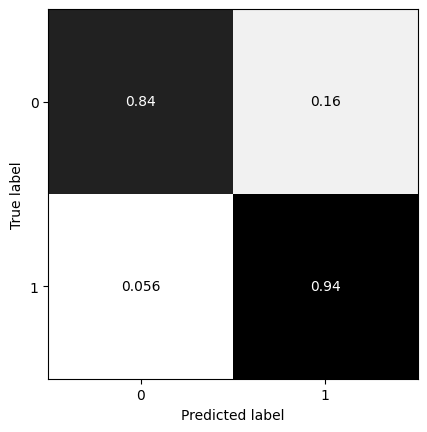

In [39]:
# Hiển thị ma trận nhầm lẫn (Confusion Matrix) để đánh giá chi tiết hiệu quả của mô hình.
# Các chỉ số trong Confusion Matrix:
# True Positive (TP): Dự đoán đúng tài khoản rủi ro.
# True Negative (TN): Dự đoán đúng tài khoản không rủi ro.
# False Positive (FP): Dự đoán nhầm tài khoản không rủi ro là rủi ro.
# False Negative (FN): Dự đoán nhầm tài khoản rủi ro là không rủi ro.
from sklearn.metrics import ConfusionMatrixDisplay
print('Accuracy of random forrest classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))
print('\nConfusion Matrix: ')
disp = ConfusionMatrixDisplay.from_predictions(y_test, clf.predict(X_test), display_labels=clf.classes_,
                                               normalize='true', cmap='Greys', colorbar=False)

**Xác Nhận Đánh Giá Mô Hình ML trên Dữ liệu Kiểm Thử (Confusion Matrix)**
Xuất điểm hiệu suất Độ Hoàn Chỉnh và hiển thị Ma trận nhầm lẫn (Tỷ lệ dự đoán đúng Nguy cơ/Không Nguy Cơ so với thực tế).

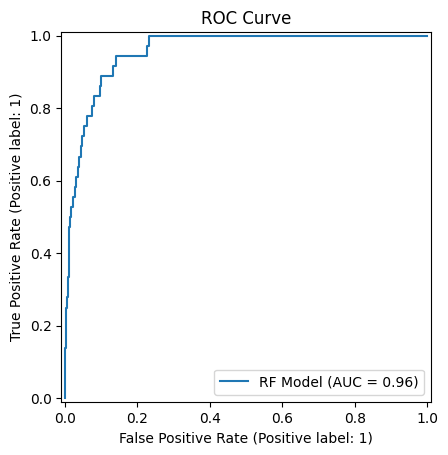

In [40]:
# Vẽ đồ thị ROC cho mô hình RandomForestClassifier.
# Giúp đánh giá trực quan khả năng phân loại của mô hình qua các mức ngưỡng phân loại khác nhau.
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_estimator(clf, X_test, y_test, name="RF Model")
_ = display.ax_.set_title("ROC Curve")

**Ma Trận ROC (Đường cong Hiệu Suất Mô Hình)**
Vẽ đường chéo ROC từ Sklearn cho kết quả Phân tách khả năng False Positive và True Positive của mô hình Rừng ngẫu nhiên.

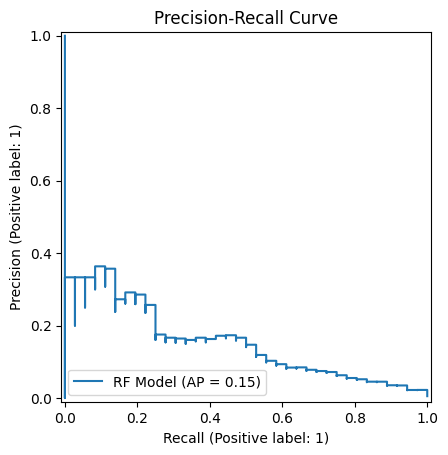

In [41]:
# Vẽ đồ thị Precision-Recall (PR Curve) cho mô hình.
# Giúp đánh giá mức độ chính xác (Precision) và khả năng thu hồi (Recall) của mô hình tại các ngưỡng khác nhau.
from sklearn.metrics import PrecisionRecallDisplay

y_prob = clf.predict_proba(X_test)
display = PrecisionRecallDisplay.from_predictions(y_test, y_prob[:, 1], name="RF Model")
_ = display.ax_.set_title("Precision-Recall Curve")

**Biểu Đồ Precision-Recall (Cho Tính Hình Mất Cân Bằng)**
Với dữ liệu Fraud, biểu đồ ROC đôi khi tối ưu sai. Precision-Recall Curve chính là biểu đồ tốt nhất để xem mức độ cân bằng giữ việc Cảnh báo Cáo Khách và Bỏ Lọt Gian lận.

Dưới đây là danh sách xếp hạng các tính năng có ảnh hưởng nhất. Trong số những tính năng quan trọng nhất là quy mô cộng đồng, mức độ chia sẻ ID và PageRank của thẻ chia sẻ P2P.

In [42]:
# Tính toán độ quan trọng của các đặc trưng bằng cách sử dụng Permutation Importance.
# Xác định những đặc trưng nào đóng góp nhiều nhất vào khả năng dự đoán của mô hình.
# Sắp xếp các đặc trưng theo mức độ quan trọng để hỗ trợ trong việc tối ưu hóa mô hình hoặc giảm số lượng đặc trưng.
from sklearn.inspection import permutation_importance
result = permutation_importance(clf, X_train, y_train, random_state=0)
pd.DataFrame(abs(result['importances_mean']),index=X_train.columns).sort_values(0, ascending=False)

,0
partOfCommunity,0.114090
communitySize,0.106522
sharedIdsDegree,0.021012
p2pSharedCardPageRank,0.015713
ipDegree,0.007827
p2pReceivedWeightedDegree,0.006181
cardDegree,0.004299
p2pReceivedWeightedPageRank,0.003172
p2pSentPageRank,0.002009
deviceDegree,0.000882


**Truy Cập Feature Importances (Mức Độ Ảnh Hưởng của Đặc Trưng)**
Sử dụng Hoán vị để kiểm tra tính quan trọng cho từng thông số Graph sinh ra ở trên. Thông số `p2pSharedCardPageRank` hoặc `ipDegree` đóng vai trò nào chi phối nhãn dự đoán cho thuật toán.

### Điều tra các dự đoán rủi ro gian lận có xác suất cao nhưng chưa được gắn nhãn
Việc gắn nhãn ở phần 2 không hoàn hảo. Giờ đây, sau khi đã huấn luyện mô hình máy học, việc điều tra các tài khoản người dùng được dự đoán là có rủi ro gian lận xác suất cao mặc dù chúng tôi không gắn nhãn như vậy (có vẻ như là dương tính giả), sẽ mang lại những hiểu biết sâu sắc hơn.

Các lệnh dưới đây sẽ tách một số trường hợp khỏi tập dữ liệu thử nghiệm để chúng ta có thể trực quan hóa trong [Neo4j Bloom](https://neo4j.com/product/bloom/)

In [43]:
# Retrieve High Probability predictions for non-fraud risk labeled data in the testset
# Retrieve High Probability predictions for non-fraud risk labeled data in the testset
# Lọc ra những tài khoản mà mô hình dự đoán có xác suất rủi ro cao (trên 0.88) nhưng thực tế chưa bị gán nhãn rủi ro.
# Liên kết thêm các thông tin như guid, wccId, communitySize để phân tích sâu hơn.
y_test_df = y_test.to_frame(name='cls')
y_test_df['predictedProbability']=y_prob[:, 1]
test_prob_df = y_test_df[(y_test_df.predictedProbability > 0.88) & (y_test_df.cls == 0)] \
    .join(df[['guid','wccId', 'communitySize']])
test_prob_df

,cls,predictedProbability,guid,wccId,communitySize
18992,0,0.897025,6a8845a1e7c682d27ea003baa717fd68,2860,18
28174,0,0.890451,61f529310505c37299e3209e441083c9,4588,4
33419,0,0.905221,0f4864c3198dea15bc7148f8bb9c43c8,275,14
11457,0,0.881914,dc820ac59af876db5842f0324d232d2a,11457,3
15078,0,0.911020,bccaaa50640b11202434dc6c0a38e0e4,250,15
14268,0,0.903130,abe84182d2b136c9f8592f7e1626a305,9140,3
11589,0,0.884929,22580fd02fc22ae402031bb81e942ed2,516,5
316,0,0.881391,8138dfbea4a1b7b8a7eade753e0806af,275,14
11279,0,0.888523,7c7b15307042a6557c712c891c5d5010,275,14


**Dự Đoán Cuối Cùng (Predictions & Sàng Lọc Rủi Ro Cao Nhất)**
Lấy xác suất `predictedProbability` cho trên tập kiểm thử (những người Máy đoán có rủi ro lớn hơn > 0.88 nhưng nhãn ban đầu lại là sạch).

Iteration 1, loss = 0.43064156
Iteration 2, loss = 0.19871334
Iteration 3, loss = 0.19272431
Iteration 4, loss = 0.16619517
Iteration 5, loss = 0.17133148
Iteration 6, loss = 0.17700933
Iteration 7, loss = 0.13773825
Iteration 8, loss = 0.16880109
Iteration 9, loss = 0.20576223
Iteration 10, loss = 0.13327872
Iteration 11, loss = 0.12285065
Iteration 12, loss = 0.13818508
Iteration 13, loss = 0.18952744
Iteration 14, loss = 0.14466827
Iteration 15, loss = 0.18940975
Iteration 16, loss = 0.15053518
Iteration 17, loss = 0.21780003
Iteration 18, loss = 0.09134084
Iteration 19, loss = 0.10890589
Iteration 20, loss = 0.19055263
Iteration 21, loss = 0.15676343
Iteration 22, loss = 0.11078557
Iteration 23, loss = 0.14059858
Iteration 24, loss = 0.11864519
Iteration 25, loss = 0.13688059
Iteration 26, loss = 0.10957913
Iteration 27, loss = 0.11332399
Iteration 28, loss = 0.13860009
Iteration 29, loss = 0.12860314
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. S

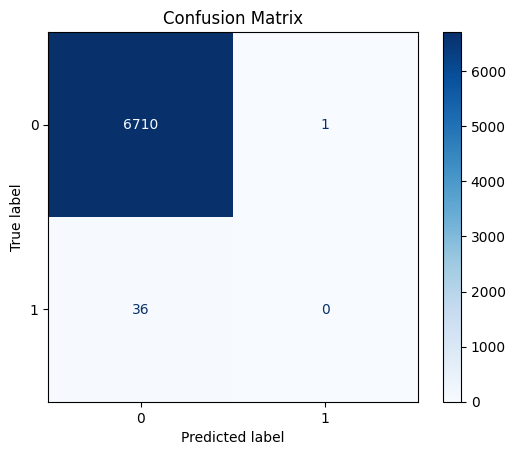

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
 
# Khởi tạo và huấn luyện MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    solver='adam',
    max_iter=500,
    random_state=42, 
    verbose=True)
mlp.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
# 4. Tính và hiển thị Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [45]:
import pandas as pd

# 1. Dự đoán xác suất trên tập kiểm tra
y_prob_mlp = mlp.predict_proba(X_test)

# 2. Chuyển y_test thành DataFrame và thêm cột xác suất dự đoán
y_test_df_mlp = y_test.to_frame(name='cls')
y_test_df_mlp['predictedProbability'] = y_prob_mlp[:, 1]

# 3. Lọc các tài khoản có xác suất rủi ro cao nhưng chưa bị gán nhãn (cls == 0)
threshold = 0.5  # Ngưỡng xác suất rủi ro cao
high_risk_df = y_test_df_mlp[
    (y_test_df_mlp['predictedProbability'] > threshold) & (y_test_df_mlp['cls'] == 0)
]

# 4. Liên kết thêm thông tin từ DataFrame gốc (df)
# Giả sử 'df' là DataFrame chứa thông tin gốc như 'guid', 'wccId', 'communitySize'
result_df = high_risk_df.join(df[['guid', 'wccId', 'communitySize']])

# 5. Hiển thị kết quả
result_df

,cls,predictedProbability,guid,wccId,communitySize
33041,0,0.868514,da1a167caa622eb15a3bad45f5df05d3,8144,4


In [46]:

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Tiền xử lý dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Áp dụng SMOTE để xử lý dữ liệu mất cân bằng
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Chia dữ liệu thành train-test
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [47]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, average_precision_score

# Khởi tạo và huấn luyện mô hình XGBoost
dtrain = xgb.DMatrix(X_new_train, label=y_new_train)
dtest = xgb.DMatrix(X_new_test, label=y_new_test)

# Chống overfitting cho XGBoost
# Giảm độ sâu cây (max_depth)
# Thêm regularization xử lý overfitting
# Giảm tốc độ học (learning_rate)
# Thêm subsample và colsample_bytree để ngẫu nhiên hóa
scale_pos_weight = len(y_new_train[y_new_train == 0]) / len(y_train[y_train == 1])
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 3, 
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'reg_alpha': 0.5,
    'reg_lambda': 1,
    'scale_pos_weight': 1,
    'random_state': 42
}

watchlist = [(dtrain, 'train'), (dtest, 'eval')]

# Sử dụng train với early stopping
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    early_stopping_rounds=50,
    evals=watchlist,
    verbose_eval=True
)


# Dự đoán xác suất
y_prob = bst.predict(dtest)

# Chuyển đổi xác suất thành nhãn với ngưỡng 0.5
y_pred = (y_prob > 0.5).astype(int)

# Đánh giá mô hình
accuracy = accuracy_score(y_new_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Báo cáo chi tiết về mô hình
print("\nClassification Report:")
print(classification_report(y_new_test, y_pred))

[0]	train-auc:0.93837	eval-auc:0.94154
[1]	train-auc:0.94210	eval-auc:0.94552
[2]	train-auc:0.94210	eval-auc:0.94552
[3]	train-auc:0.94210	eval-auc:0.94552
[4]	train-auc:0.94128	eval-auc:0.94452
[5]	train-auc:0.95349	eval-auc:0.95535
[6]	train-auc:0.95549	eval-auc:0.95710
[7]	train-auc:0.95382	eval-auc:0.95571
[8]	train-auc:0.95351	eval-auc:0.95537
[9]	train-auc:0.95391	eval-auc:0.95585
[10]	train-auc:0.95635	eval-auc:0.95807
[11]	train-auc:0.95644	eval-auc:0.95815
[12]	train-auc:0.95630	eval-auc:0.95796
[13]	train-auc:0.95664	eval-auc:0.95834
[14]	train-auc:0.95695	eval-auc:0.95867
[15]	train-auc:0.95980	eval-auc:0.96182
[16]	train-auc:0.95983	eval-auc:0.96186
[17]	train-auc:0.96025	eval-auc:0.96231
[18]	train-auc:0.96052	eval-auc:0.96247
[19]	train-auc:0.96082	eval-auc:0.96274
[20]	train-auc:0.96315	eval-auc:0.96503
[21]	train-auc:0.96337	eval-auc:0.96534
[22]	train-auc:0.96602	eval-auc:0.96802
[23]	train-auc:0.96651	eval-auc:0.96843
[24]	train-auc:0.96708	eval-auc:0.96904
[25]	train

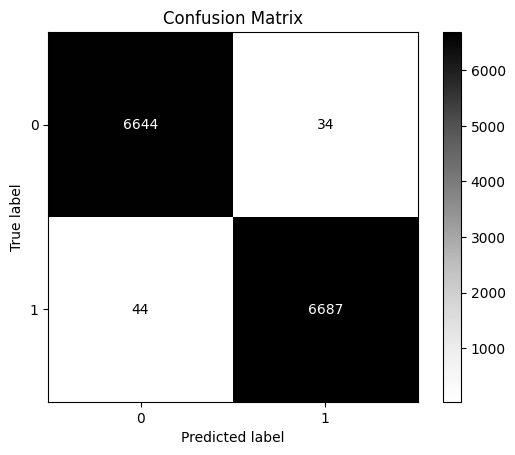

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_new_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Greys')
plt.title("Confusion Matrix")
plt.show()

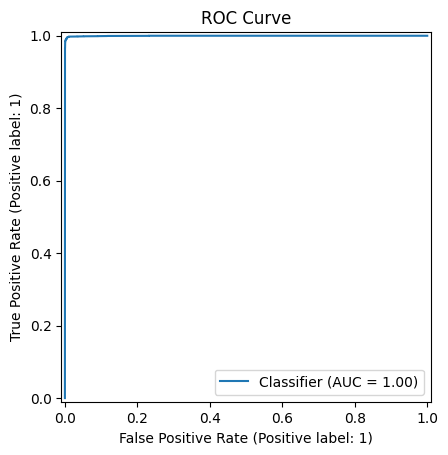

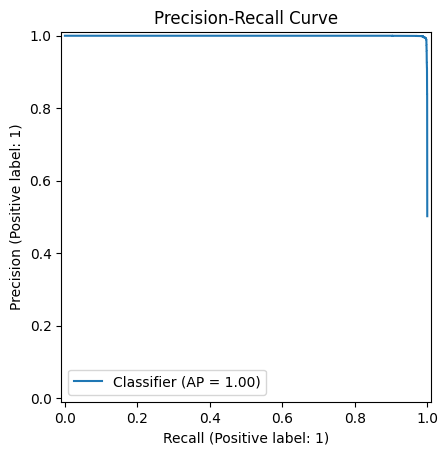

In [49]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# ROC Curve
RocCurveDisplay.from_predictions(y_new_test, y_prob).ax_.set_title("ROC Curve")
plt.show()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_new_test, y_prob).ax_.set_title("Precision-Recall Curve")
plt.show()

In [50]:
#Ghi lại thông tin vào cơ sở dữ liệu để điều tra trong Bloom
for index, row in test_prob_df.iterrows():
    gds.run_cypher('''
        MATCH(u:User) WHERE u.guid = $guid
        SET u.predictedProbability = $predictedProbability
    ''', params = row.to_dict())

**Viết Kết Quả Vét Cạn Xác Suất Ngược Trở Lại Graph Database (Bloom)**
Toàn bộ xác xuất này sẽ được lưu về Neo4j thành các Node Attributes để nhóm điều tra có thể dùng công cụ trực quan hóa dực hình như Neo4j Bloom để kiểm chứng người thật - đồ thị thật.

Dưới đây là một vài ví dụ từ tập dữ liệu thử nghiệm được trực quan hóa trong [Bloom](https://neo4j.com/docs/bloom-user-guide/current/). Các nút màu xanh lá cây lớn hơn, nằm ở phía bên trái, với biểu tượng người dùng đại diện cho các nút có xác suất cao đáng quan tâm.

Ví dụ 1
<img src="img/predictions-in-bloom-1.png" width="700" >\n

Ví dụ 2
<img src="img/predictions-in-bloom-2.png" width="700" >

Có lẽ không có gì đáng ngạc nhiên, chúng thể hiện hành vi giao dịch P2P dùng chung thẻ, chúng cũng có số lượng thẻ tín dụng tương đối lớn (độ trung tâm trung bình trên các thẻ là 3). Điều này có thể là dấu hiệu của gian lận, mặc dù rất khó để biết được trên một tập dữ liệu ẩn danh như thế này. Đây là lúc cần đến sự xem xét và lặp lại của chuyên gia. Nếu hành vi này hóa ra là một dấu hiệu rõ ràng của gian lận, điều đó có nghĩa là chúng ta đang dự đoán gian lận một cách chủ động hơn trước khi xảy ra các khoản hoàn trả, đó là điều lý tưởng. Trong trường hợp này, nếu chúng ta gắn nhãn lại cho những người dùng này một cách phù hợp và huấn luyện lại mô hình học máy khi có thêm dữ liệu, chúng ta sẽ cải thiện hơn nữa hiệu suất dự đoán. Mặt khác, nếu hóa ra một số hành vi này là vô hại, chúng ta có thể điều chỉnh kỹ sư trích chọn đặc trưng và mô hình để học máy học cách loại bỏ những trường hợp như vậy, điều này cũng sẽ cải thiện hiệu suất dự đoán và tăng cường hiểu biết của chúng ta về các mô hình gian lận. Dù bằng cách nào, đó cũng là một thành công.

## Clean Up
This section will help clean all the additional graph elements and properties created in the above workflow.

In [51]:
# delete created relationships
gds.run_cypher('MATCH (:User)-[r:SHARED_IDS]->() DELETE r')
gds.run_cypher('MATCH (:User)-[r:P2P_WITH_SHARED_CARD]->() DELETE r')
gds.run_cypher('MATCH (:User)-[r:SIMILAR_IDS]->() DELETE r')

""


**Dọn Dẹp Đồ Thị 1 (Gỡ bỏ Relationships do Thuật Toán Sinh Ra)**
Xóa các biểu thức liên kết in-memory giả lập các định dạng chia sẻ, trả đồ thị lại kết nối thô P2P nguyên bản ban đầu.

In [52]:
# remove created node Labels
gds.run_cypher('MATCH (u:FlaggedUser) REMOVE u:FlaggedUser')
gds.run_cypher('MATCH (u:FraudRiskUser) REMOVE u:FraudRiskUser')
gds.run_cypher('MATCH (u:FraudSharedId) REMOVE u:FraudSharedId')

""


**Dọn Dẹp Đồ Thị 2 (Gỡ Nhãn Tạm Thời)**
Xóa những Label gán tự động (`FraudRiskUser`, `FraudSharedId`) của bước phân tích cộng đồng lừa đảo bằng Cypher.

In [53]:
# remove created node properties
gds.run_cypher('''
    MATCH (n)
    REMOVE n.wccId,
        n.sharedIdsDegree,
        n.predictedProbability,
        n.partOfCommunity,
        n.p2pSharedCardPageRank,
        n.p2pSharedCardDegree,
        n.p2pSentWeightedPageRank,
        n.p2pSentWeightedDegree,
        n.p2pSentPageRank,
        n.p2pSentDegree,
        n.p2pReversedSharedCardPageRank,
        n.p2pReversedSharedCardDegree,
        n.p2pReceivedWeightedPageRank,
        n.p2pReceivedWeightedDegree,
        n.p2pReceivedPageRank,
        n.p2pReceivedDegree,
        n.louvainCommunityId,
        n.ipDegree,
        n.fraudRiskRatio,
        n.fraudRiskDegree,
        n.fraudRisk,
        n.flaggedRatio,
        n.flaggedDegree,
        n.deviceDegree,
        n.degree,
        n.communitySize,
        n.cardDegree
''')

""


**Dọn Dẹp Đồ Thị 3 (Gỡ Thuộc Tính Sinh Ra ML)**
Xóa sổ tất cả các Degree Variables, WccId, các nhãn tính chất Feature Engineering cho Machine Learning để database không phình to không cần thiết.

In [54]:
# remove created relationship properties
gds.run_cypher('MATCH ()-[r]->() REMOVE r.inverseDegreeWeight')

""


**Dọn Dẹp Đồ Thị 4 (Gỡ Trọng Số Similary)**
Xóa kết nối trọng suất tương đồng trên Relationship.